# Pandas 과제
***를 채워주세요!

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
titanic = sns.load_dataset('titanic')
print("titanic 변수 type: ", type(titanic))

titanic 변수 type:  <class 'pandas.core.frame.DataFrame'>


실습에서 진행했던 것 처럼, 대부분의 경우 csv파일 등 외부 파일에서 데이터를 불러와 사용하게 됩니다.<br>
그게 아니라면 리스트나 딕셔너리 형태로 만든 데이터를 데이터프레임으로 변환하고요.<br>

이번 과제에서는 타이타닉이라는, Seaborn 라이브러리에 내장된 데이터셋을 불러와서 사용할 겁니다.(다음 차시에서 또 쓸 거에요!)

# 데이터 확인 
## 데이터 확인 파트는 코드를 작동만 해보세요!!

In [2]:
data = titanic
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [3]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("DataFrame 크기: ", titanic.shape)

DataFrame 크기:  (891, 15)


In [6]:
value_counts = data["survived"].value_counts()
print(value_counts)

survived
0    549
1    342
Name: count, dtype: int64


데이터의 개형을 간단하게 확인해봤습니다.<br>
이제 배운 내용을 활용해봅시다!

# 데이터 추출
## 열 단위 추출하기 - 단일 칼럼

### 인덱싱을 활용해 survived 칼럼을 추출하기

In [7]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [9]:
# 추출한 데이터를 surv라는 새로운 변수에 할당해보아요
# 코드의 형태는 **** = ****['********']
surv = data['survived']

#잘 저장되었는지 확인해보고, 저장된 데이터의 데이터타입을 확인해보아요
print(surv)
type(surv)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64


pandas.core.series.Series

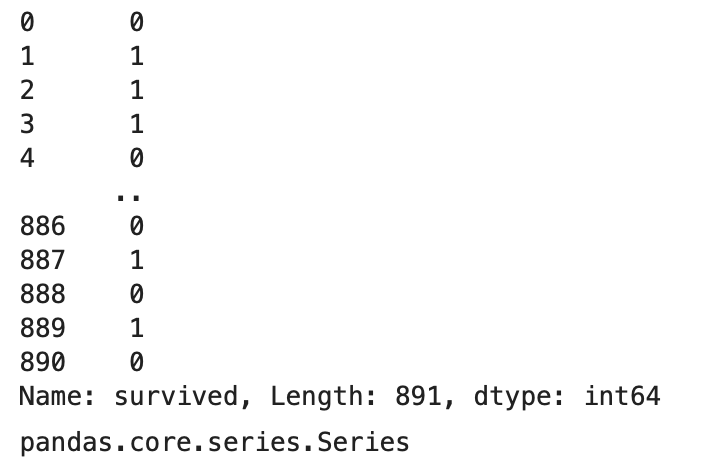

단일 칼럼에 인덱싱을 사용할 경우, 값이 시리즈 형태로 반환된다는 사실을 알 수 있어요.

동일한 결과를 loc과 iloc을 사용해서도 얻어보아요~

### loc을 사용해 survived 열 추출하기

In [10]:
# loc을 사용해서도 단일 열을 추출할 수 있어요
# 데이터프레임.loc[ 행, 열 ]의 구조를 사용하면 됩니다.
# 행 전체를 가져오고 싶을 때에는 행 자리에 :를 넣으면 돼요
surv1 = data.loc[:, 'survived']

print(surv1)
type(surv1)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64


pandas.core.series.Series

위와 정확히 동일한 결과가 나오면 정답!

### iloc을 사용해 survived 열 추출하기

In [11]:
# iloc은 이름으로 동작하는 loc과 달리 정수형 인덱스 번호가 와야해요
# 다른 구조는 loc과 동일하나, 열을 넣을 자리에 'survived'대신 숫자를 입력해야합니다.
# 번호는 왼쪽에서부터 칼럼을 세어서 0, 1, 2, ... 순으로 매겨집니다.
# 그럼 이제 survived 칼럼을 iloc을 사용해 추출해봅시다!
surv2 = data.iloc[:, 0]

print(surv2)
type(surv2)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64


pandas.core.series.Series

인덱싱과 결과는 동일합니다!

### (추가) 만약 단일 칼럼을 인덱싱해야하지만, 데이터프레임 형태를 유지하려면?

 1. 인덱싱의 경우, 전달하는 칼럼 명을 대괄호로 한번 더 감싸, 리스트 형태로 전달
 - surv = data[['survived']]
 2. loc도 마찬가지! 이를 Fancy 인덱싱이라고 부른다.
 - surv1 = data.loc[:, ['survived']]
 3. iloc은 loc과 동일하다.
 - surv2 = data.iloc[:, ['survived']]

In [12]:
# 인덱싱 사용해 데이터프레임 형태로 가져오기
surv = data[['survived']]
surv

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


결과의 형태가 아까와는 다르죠? 데이터프레임 타입으로 가져와서 그렇습니다.

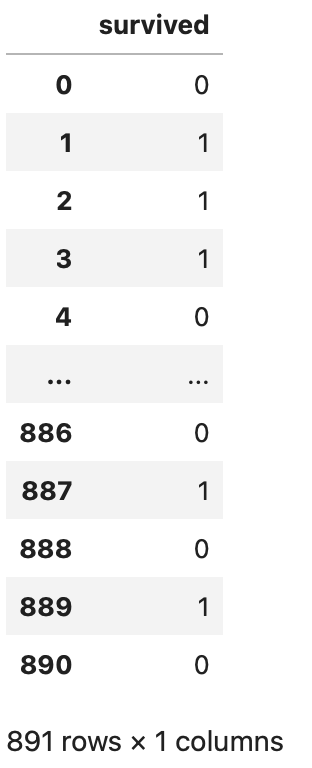

인덱싱과 동일한 결과가 나오면 정답!

In [16]:
# loc 사용해 데이터프레임 형태로 가져오기
surv1 = data.loc[:, ['survived']]
surv1

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


인덱싱과 동일한 결과가 나오면 정답!

In [17]:
# iloc 사용해 데이터프레임 형태로 가져오기
surv2 = data.iloc[:, [0]]
surv2

,survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


인덱싱과 동일한 결과가 나오면 정답!

In [18]:
# type()함수를 사용해 정말 데이터프레임 형태로 가져왔는지 확인해봅시다
print(type(surv), type(surv1), type(surv2))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


전부 데이터 프레임 형태로 바뀐 것을 확인할 수 있습니다.

## 열 단위 추출 - 다중 칼럼

### 인덱싱을 활용해 'age', 'sibsp', 'parch' 열 추출하기

인덱싱을 통해서도 여러 칼럼을 동시에 추출할 수 있습니다.

[주의사항]<br>
두 개 이상의 칼럼을 동시에 인덱싱하려면, 반드시 리스트 형태로 자료를 제공해야 합니다.<br>
예를 들어, 'age', 'sibsp', 'parch' 세 칼럼을 추출하려면, 이들을 ['age', 'sibsp', 'parch']와 같이 대괄호로 묶어 인덱싱해야 합니다.


[오류가 발생하는 경우]<br>
만약 대괄호를 추가하지 않고, 'age', 'sibsp', 'parch' 형태로 전달하면 오류가 발생합니다.<br>
이는 'age'와 'sibsp'와 'parch' 각각의 열을 탐색하는 것이 아니라, 'age', 'sibsp', 'parch'라는 하나의 이름을 가진 열을 탐색하라고 명령한 것이기 때문입니다.

In [24]:
#인덱싱을 사용해 다중 칼럼을 추출해봅시다

df = data[['age','sibsp','parch']]
df

,age,sibsp,parch
0,22.0,1,0
1,38.0,1,0
2,26.0,0,0
3,35.0,1,0
4,35.0,0,0
...,...,...,...
886,27.0,0,0
887,19.0,0,0
888,NaN,1,2
889,26.0,0,0


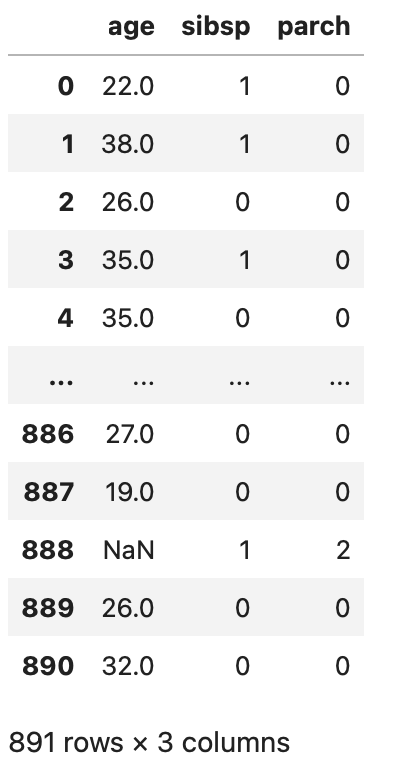

*참고 : 대괄호를 한 번 씌우면 벌어지는 일

여러개의 열을 전달하려면, 열을 리스트 형태로 요청을 해야 합니다. ["pclass", "age"]<br>
지금 상태는 "pclass"와 "age"라는 두 개의 열을 요청한 것이 아니라, ("pclass","age")라는 하나의 열을 요청한 것으로 인식됩니다.<br>
그렇기 때문에 KeyError가 발생한 것입니다.

In [ ]:
# 여러개의 열을 인덱싱할 때 괄호를 한 번 씌우면 오류 발생
# 하단의 코드에서 #를 없애고 작동시켜보세요!

# data["pclass", "age"]

KeyError: ('pclass', 'age')

### loc 사용하기

In [29]:
#단일 칼럼 추출과 거의 비슷하나, 열 이름을 리스트 형태로 제공해야 한다는 점에 차이가 있습니다.
# loc과 iloc에서 전체 행을 가져오려면 어떻게 했어야 했죠?

df1 = data.loc[:, 'age':'parch']
df1

,age,sibsp,parch
0,22.0,1,0
1,38.0,1,0
2,26.0,0,0
3,35.0,1,0
4,35.0,0,0
...,...,...,...
886,27.0,0,0
887,19.0,0,0
888,NaN,1,2
889,26.0,0,0


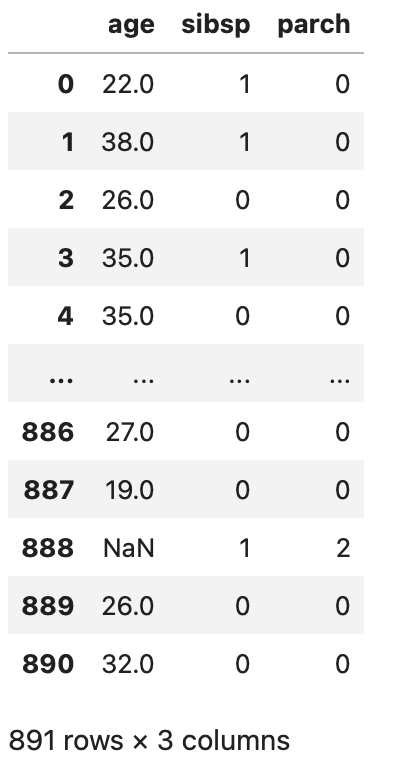

### iloc 사용하기

iloc 역시 크게 다르지 않아요<br>다만 차이점이 있다면, iloc은 칼럼 정보 인지 부분을 리스트로 전달해서는 안됩니다!

> 참고) loc에서도 열 단위 추출에 슬라이싱을 사용할 수 있습니다.<br>
> 다만 차이점은 iloc은 3번째 부터 6번째 전까지라는 범위를 제공해주는 것이지만, (data.iloc[:, 3:6])<br>
> loc을 사용하여 슬라이싱하는 경우에는 그 이름을 직접적으로 제공해주어야 합니다. (data.loc[:, 'age':'parch'])

In [31]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [33]:
#슬라이싱을 사용해 칼럼을 추출해보세요!

df2 = data.iloc[:, 3:6]
df2

,age,sibsp,parch
0,22.0,1,0
1,38.0,1,0
2,26.0,0,0
3,35.0,1,0
4,35.0,0,0
...,...,...,...
886,27.0,0,0
887,19.0,0,0
888,NaN,1,2
889,26.0,0,0


loc과 동일한 결과가 나오면 정답!

## 행단위 추출하기

### 슬라이싱 활용해 101~200번째 행을 추출하기

슬라이싱은 범위를 지정해 여러 항목을 추출할 때 사용합니다.<br>
슬라이싱은 start와 end 포인트 값을 제공해주어야 하고, 이 사이에 : 를 붙입니다.<br>
슬라이싱은 iloc처럼 번호를 기준으로 작동하며, 끝 인덱스는 포함되지 않는다는 특징이 있습니다.<br>
따라서 7번째 칼럼까지 추출하고 싶다면, 7+1 =8을 엔드 포인트로 제공해야합니다.

In [40]:
df = data[100:201]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
100,0,3,female,28.0,0,0,7.8958,S,Third,woman,False,NaN,Southampton,no,True
101,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
102,0,1,male,21.0,0,1,77.2875,S,First,man,True,D,Southampton,no,False
103,0,3,male,33.0,0,0,8.6542,S,Third,man,True,NaN,Southampton,no,True
104,0,3,male,37.0,2,0,7.9250,S,Third,man,True,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,0,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
197,0,3,male,42.0,0,1,8.4042,S,Third,man,True,NaN,Southampton,no,False
198,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
199,0,2,female,24.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,no,True


이런 식으로 나오면 성공!

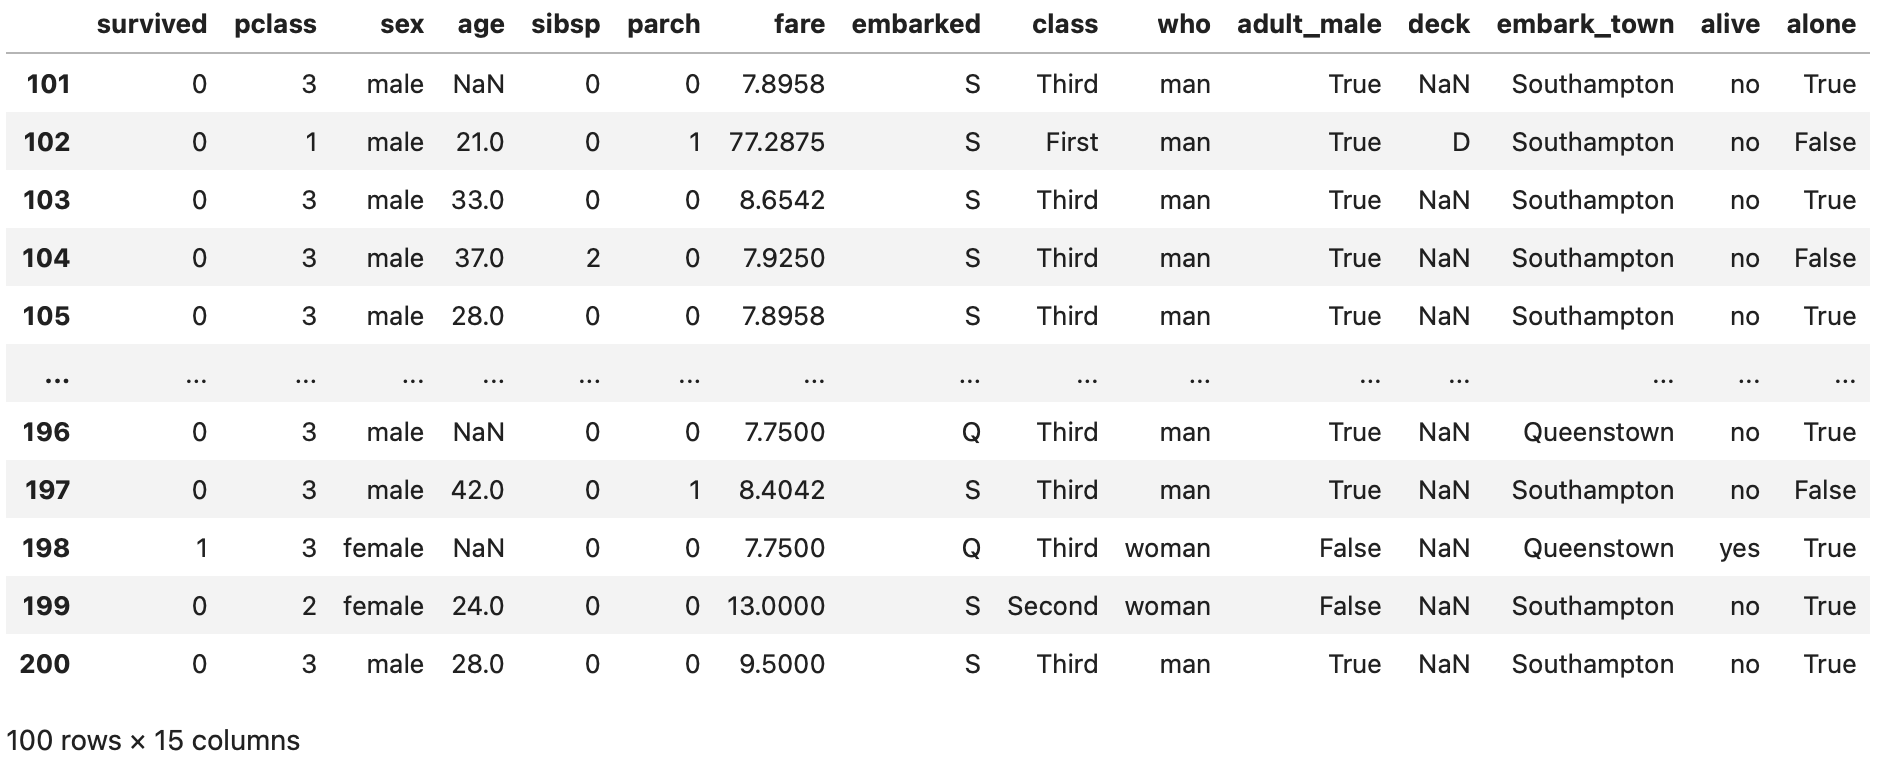

### loc을 이용해 201~300번째 행을 추출하기

**loc**은 인덱싱과 슬라이싱이 모두 가능합니다.  
하지만 일반적인 슬라이싱과 달리, 슬라이싱의 끝 인덱스에 해당하는 값까지 포함해서 가져옵니다.  
이러한 차이는 loc이 이름을 기준으로 슬라이싱하고, iloc은 번호를 기준으로 하기 때문에 발생합니다.

<행과 열 추출>   
열을 추출할 때는 ['행', '열'] 형태로 작성합니다. 만약 전체 행을 대상으로 하려면 앞에 :를 붙여 [:, '열']처럼 명시해야 합니다.  
반면, 특정 행 구간만 추출할 때는 뒤에 :를 붙여 전체 열을 대상으로 한다는 것을 명시해도 되고, 생략해도 동일한 결과를 얻습니다.  

df_row1 = data.loc[201:300, :]  # 열 전체를 명시적으로 지정  
df_row2 = data.loc[201:300]      # 열 전체를 생략 (동일한 결과)

In [38]:
df1 = data.loc[200:300]
df1

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
200,0,3,male,28.0,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
201,0,3,male,NaN,8,2,69.5500,S,Third,man,True,NaN,Southampton,no,False
202,0,3,male,34.0,0,0,6.4958,S,Third,man,True,NaN,Southampton,no,True
203,0,3,male,45.5,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
204,1,3,male,18.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,0,3,male,23.5,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
297,0,1,female,2.0,1,2,151.5500,S,First,child,False,C,Southampton,no,False
298,1,1,male,NaN,0,0,30.5000,S,First,man,True,C,Southampton,yes,True
299,1,1,female,50.0,0,1,247.5208,C,First,woman,False,B,Cherbourg,yes,False


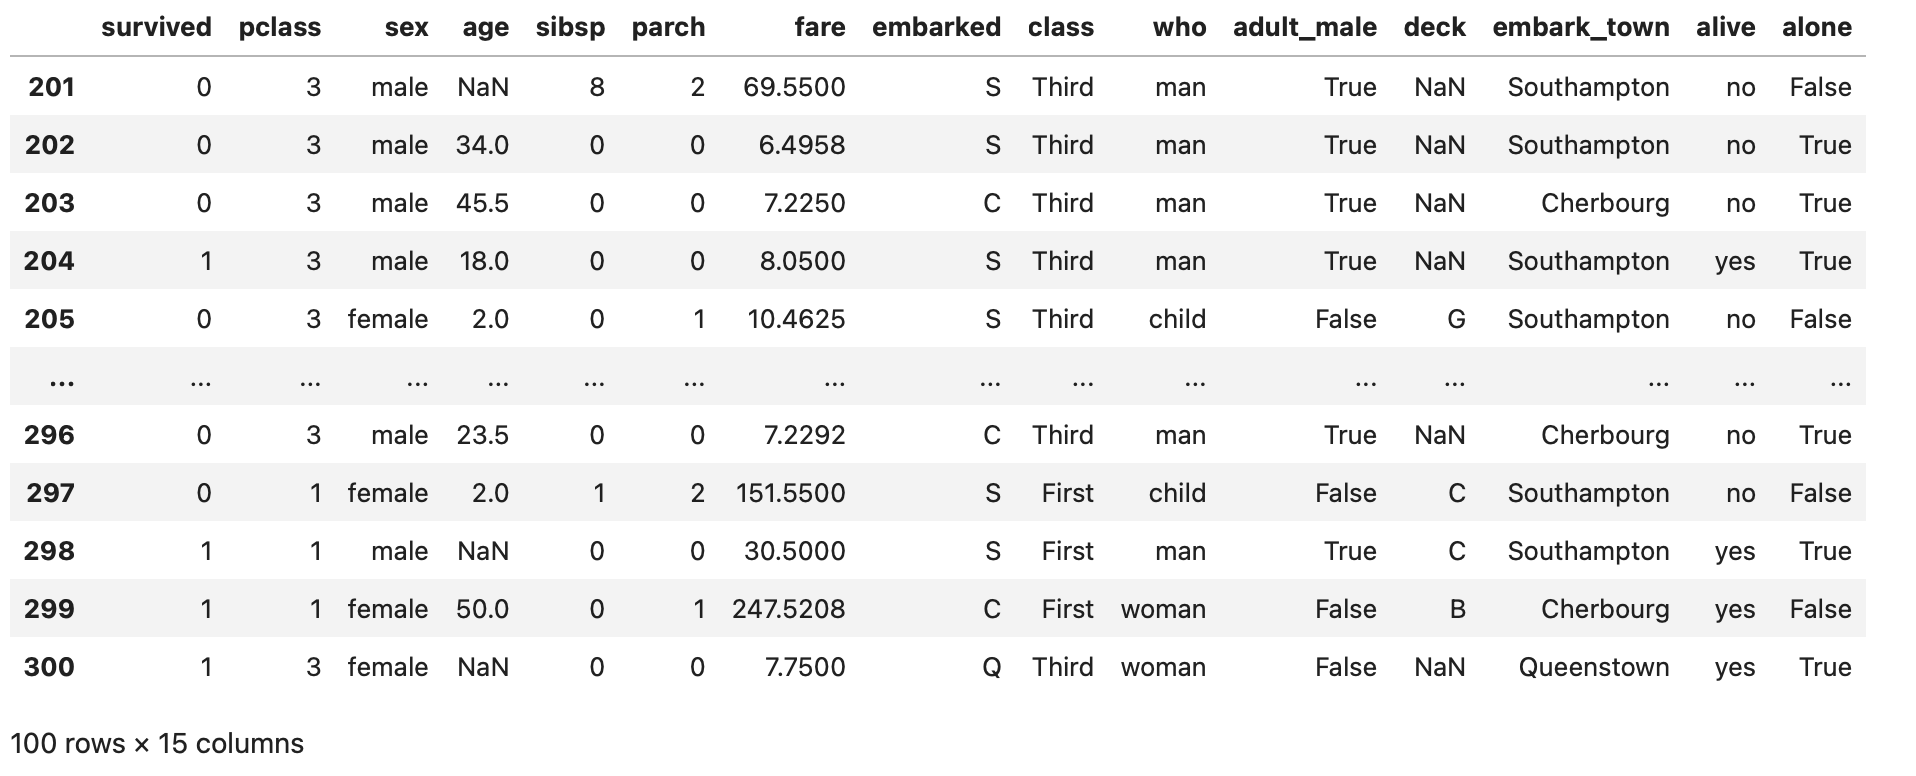

### iloc을 활용해 301~400번째 행 추출하기

In [41]:
#위의 loc과 거의 유사합니다.
#하나의 차이점은 loc의 경우 이름을 전달하는 방식이기에, 끝 인덱스도 포함이 됩니다.
#하지만 iloc의 경우에는 끝 인덱스를 포함하지 않기 때문에, 슬라이싱의 경우와 같이 끝 인덱스 + 1 을 해줘야 합니다.

df2 = data.iloc[300:401]
df2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
300,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
301,1,3,male,NaN,2,0,23.2500,Q,Third,man,True,NaN,Queenstown,yes,False
302,0,3,male,19.0,0,0,0.0000,S,Third,man,True,NaN,Southampton,no,True
303,1,2,female,NaN,0,0,12.3500,Q,Second,woman,False,E,Queenstown,yes,True
304,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
396,0,3,female,31.0,0,0,7.8542,S,Third,woman,False,NaN,Southampton,no,True
397,0,2,male,46.0,0,0,26.0000,S,Second,man,True,NaN,Southampton,no,True
398,0,2,male,23.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
399,1,2,female,28.0,0,0,12.6500,S,Second,woman,False,NaN,Southampton,yes,True


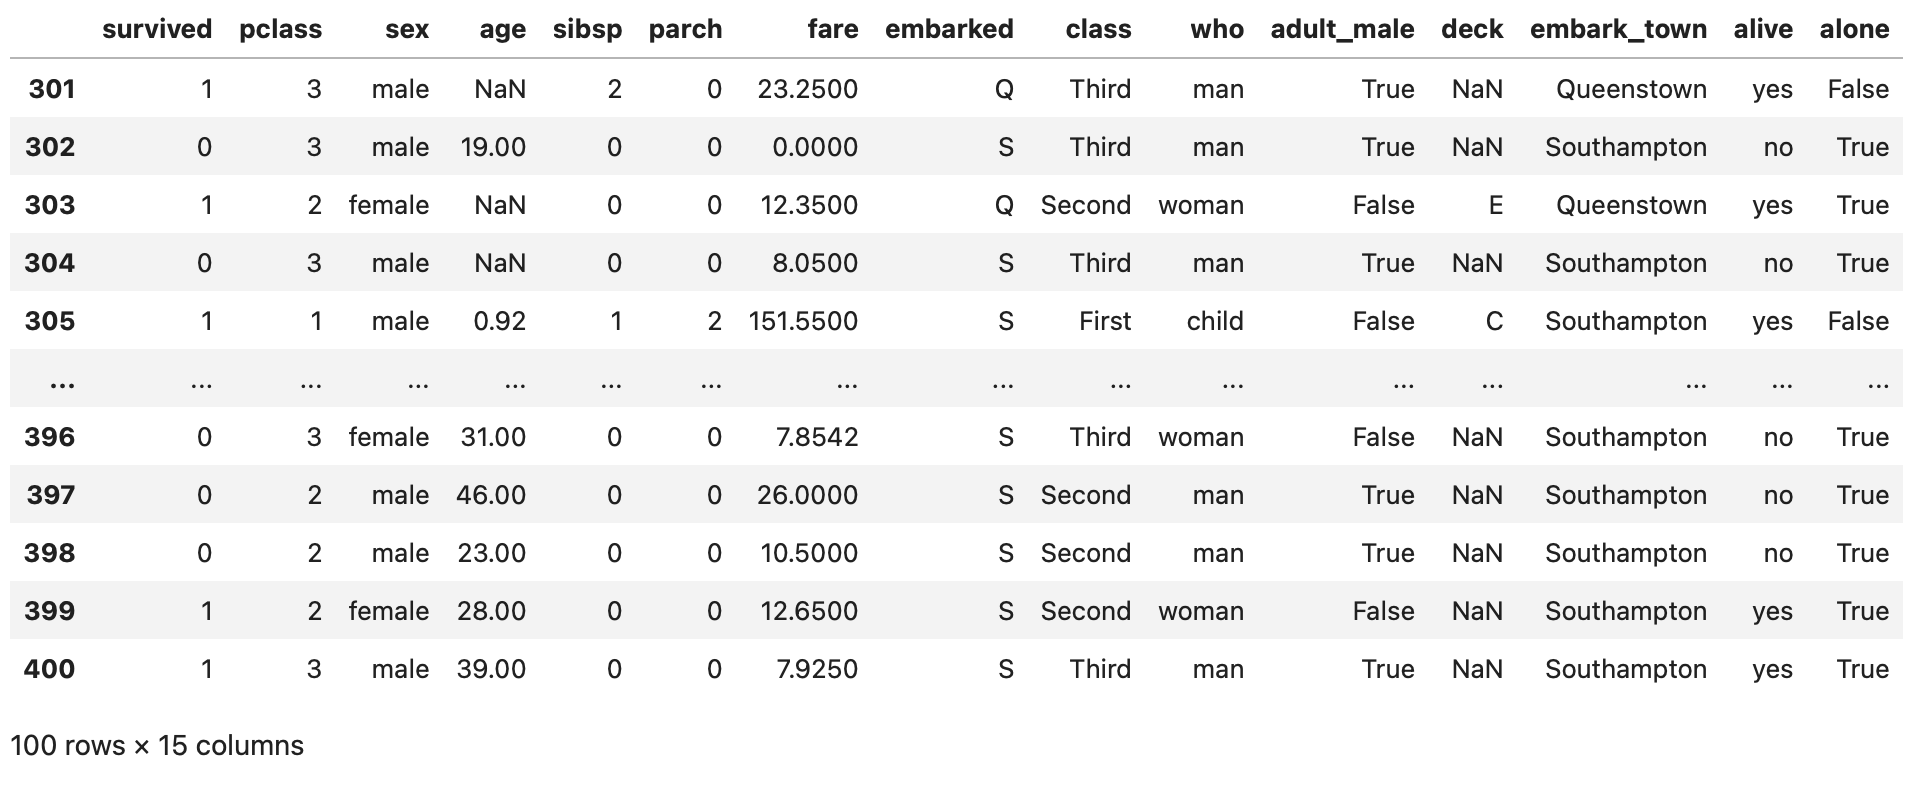

이렇게 열 단위, 행 단위 추출을 각각 배웠습니다!!

## 행과 열 복합 조건 추출

이제 이걸 응용해서 주어진 조건에 따라 열과 행을 선택해 추출하는 문제를 풀어봅시다.   
데이터 명칭은 df로 통일하겠습니다

### loc을 사용하여 행은 100~120, 열은 'age', 'fare' 열을 추출해주세요

In [44]:
df = data.loc[100:120, ['age','fare']]
df

,age,fare
100,28.0,7.8958
101,NaN,7.8958
102,21.0,77.2875
103,33.0,8.6542
104,37.0,7.9250
105,28.0,7.8958
106,21.0,7.6500
107,NaN,7.7750
108,38.0,7.8958
109,NaN,24.1500


1번 정답 :

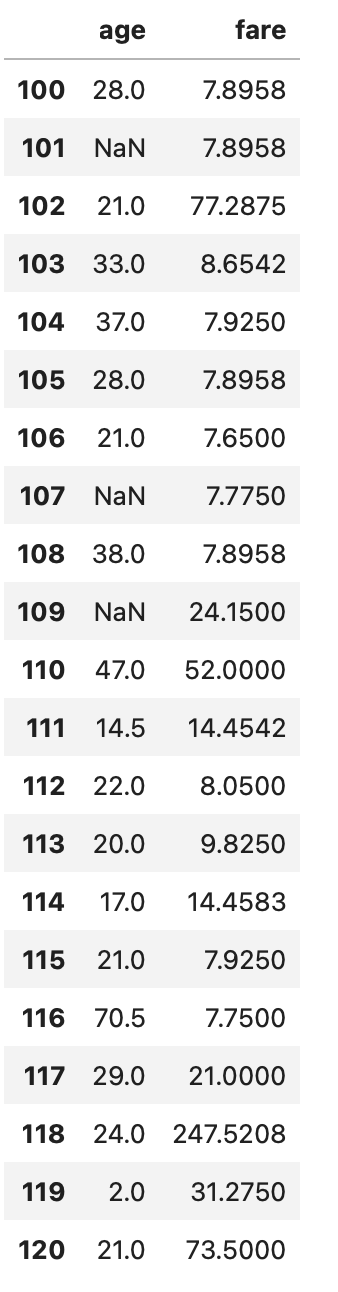

### loc을 사용하여 0, 2, 4, 7번째 행을 Fancy 인덱싱하고 열 'age'부터 'fare'까지 라벨 슬라이싱하여 추출하기

In [56]:
# Fancy 인덱싱이란 행 범위를 지정해줄 위치에 리스트 형태로 행을 전달하는 것이었죠!
# data.loc[(행 범위), (열 범위)] 중 행 범위에 리스트 정보를 전달하면 됩니다!
df = data.loc[(0,2,4,7),'age':'fare']

df

,age,sibsp,parch,fare
0,22.0,1,0,7.250
2,26.0,0,0,7.925
4,35.0,0,0,8.050
7,2.0,3,1,21.075


2번 정답: 

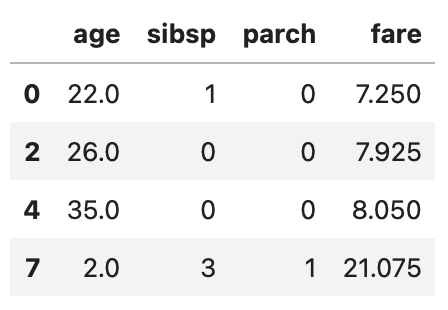

### iloc을 사용하여 10~20번째 행, 2번째 열 부터 5번째 열까지 추출해주세요

In [47]:
df = data.iloc[9:20, 1:5]
df

,pclass,sex,age,sibsp
9,2,female,14.0,1
10,3,female,4.0,1
11,1,female,58.0,0
12,3,male,20.0,0
13,3,male,39.0,1
14,3,female,14.0,0
15,2,female,55.0,0
16,3,male,2.0,4
17,2,male,NaN,0
18,3,female,31.0,1


3번 정답 :  
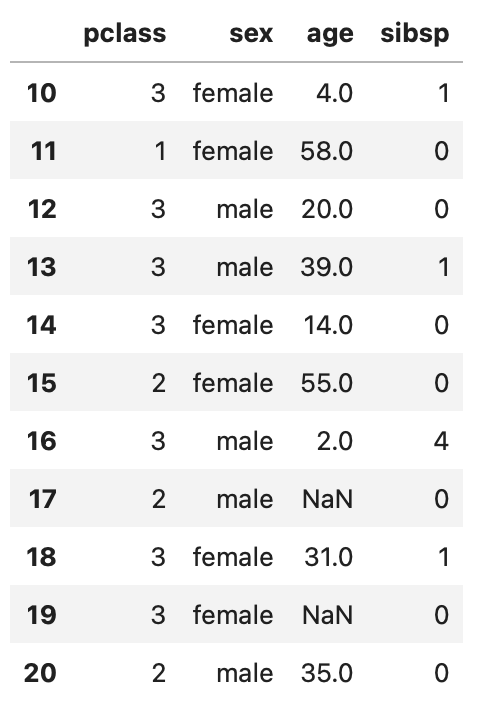

### iloc을 사용하여 행 [0, 2, 4, 6], 열 [1, 3, 5]을 추출해주세요(리스트로 전달하는 방식이나 슬라이싱 모두 사용 가능)

In [48]:
df = data.iloc[[0,2,4,6],[1,3,5]]
df

,pclass,age,parch
0,3,22.0,0
2,3,26.0,0
4,3,35.0,0
6,1,54.0,0


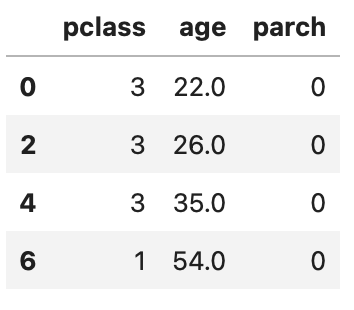

### loc을 사용해 행 라벨 200번, 열 ['survived','pclass','sex']를 추출해주세요. 단, 데이터프레임 자료형을 유지하세요

In [63]:
df = data.loc[[200], ['survived','pclass','sex']]

print(df)
type(df)

     survived  pclass   sex
200         0       3  male


pandas.core.frame.DataFrame

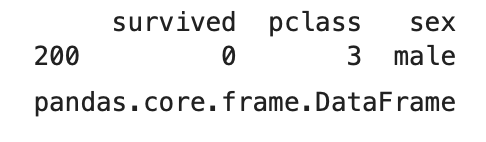

### iloc을 사용하여 행 라벨 200번의 단일 행, 그리고 0부터 3번째까지의 열을 슬라이스를 활용해 추출해주세요

In [61]:
df = data.iloc[[200],0:3]
print(df)
type(df)

     survived  pclass   sex
200         0       3  male


pandas.core.frame.DataFrame

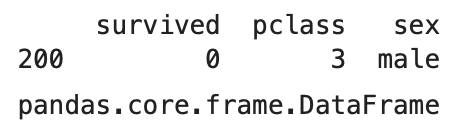

# 불리언 인덱싱
## df[조건문]

### adult_male 칼럼에서 값이 True인 행만 추출하기

In [64]:
df = data[data['adult_male']==True]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
12,0,3,male,20.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


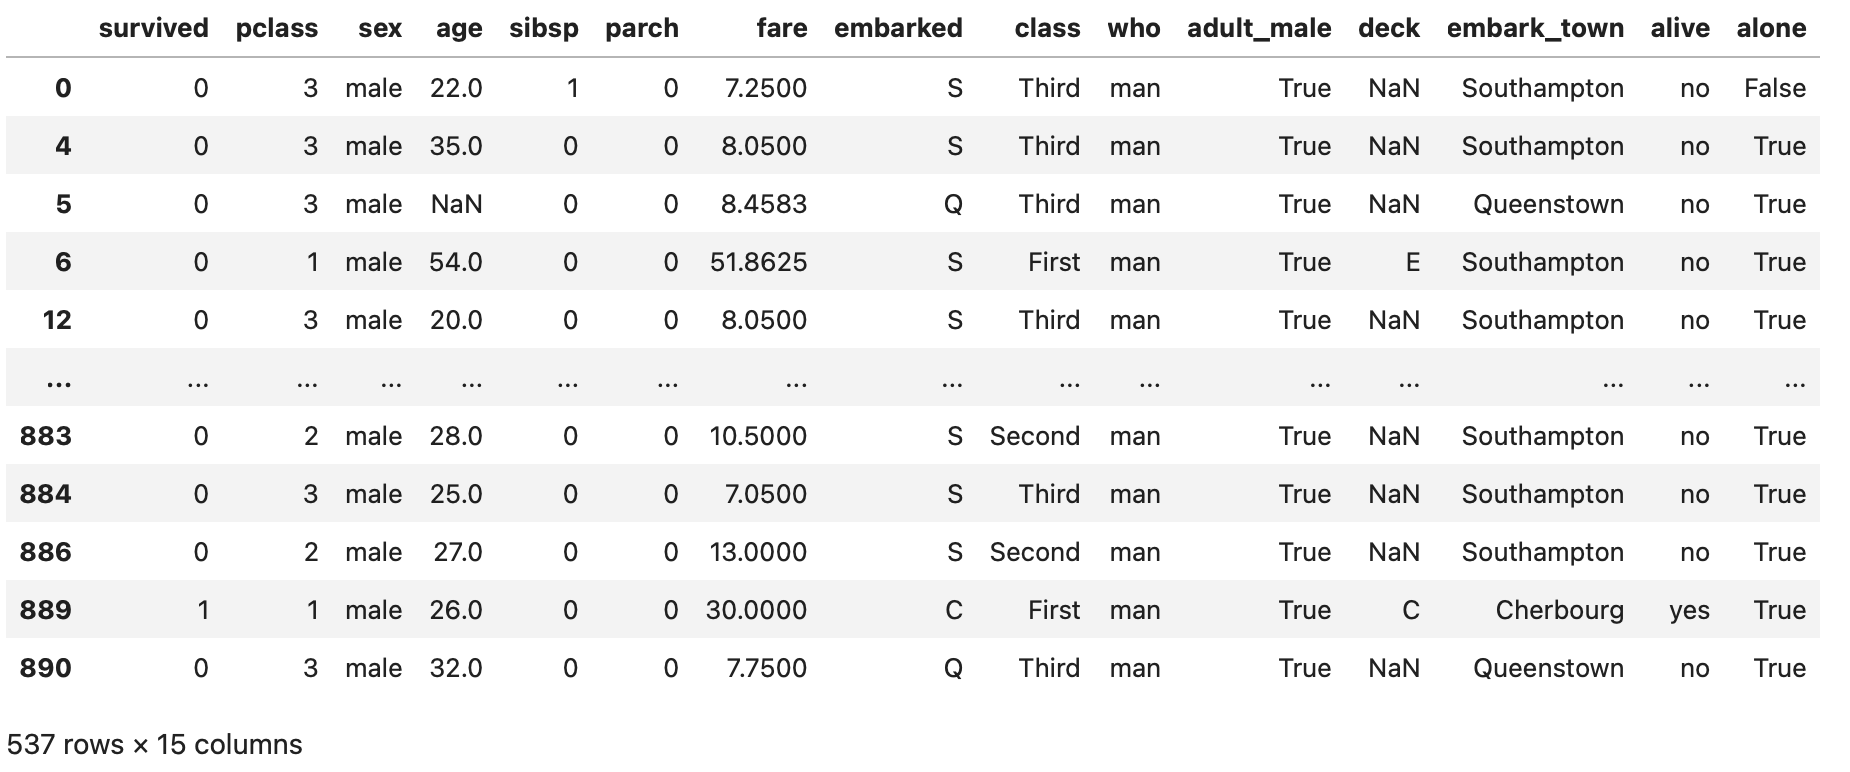

### age 열을 활용해 나이가 20세 미만인 행만 추출하기

In [66]:
df = data[data['age']<20]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
14,0,3,female,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True
16,0,3,male,2.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
855,1,3,female,18.0,0,1,9.3500,S,Third,woman,False,NaN,Southampton,yes,False
869,1,3,male,4.0,1,1,11.1333,S,Third,child,False,NaN,Southampton,yes,False
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True


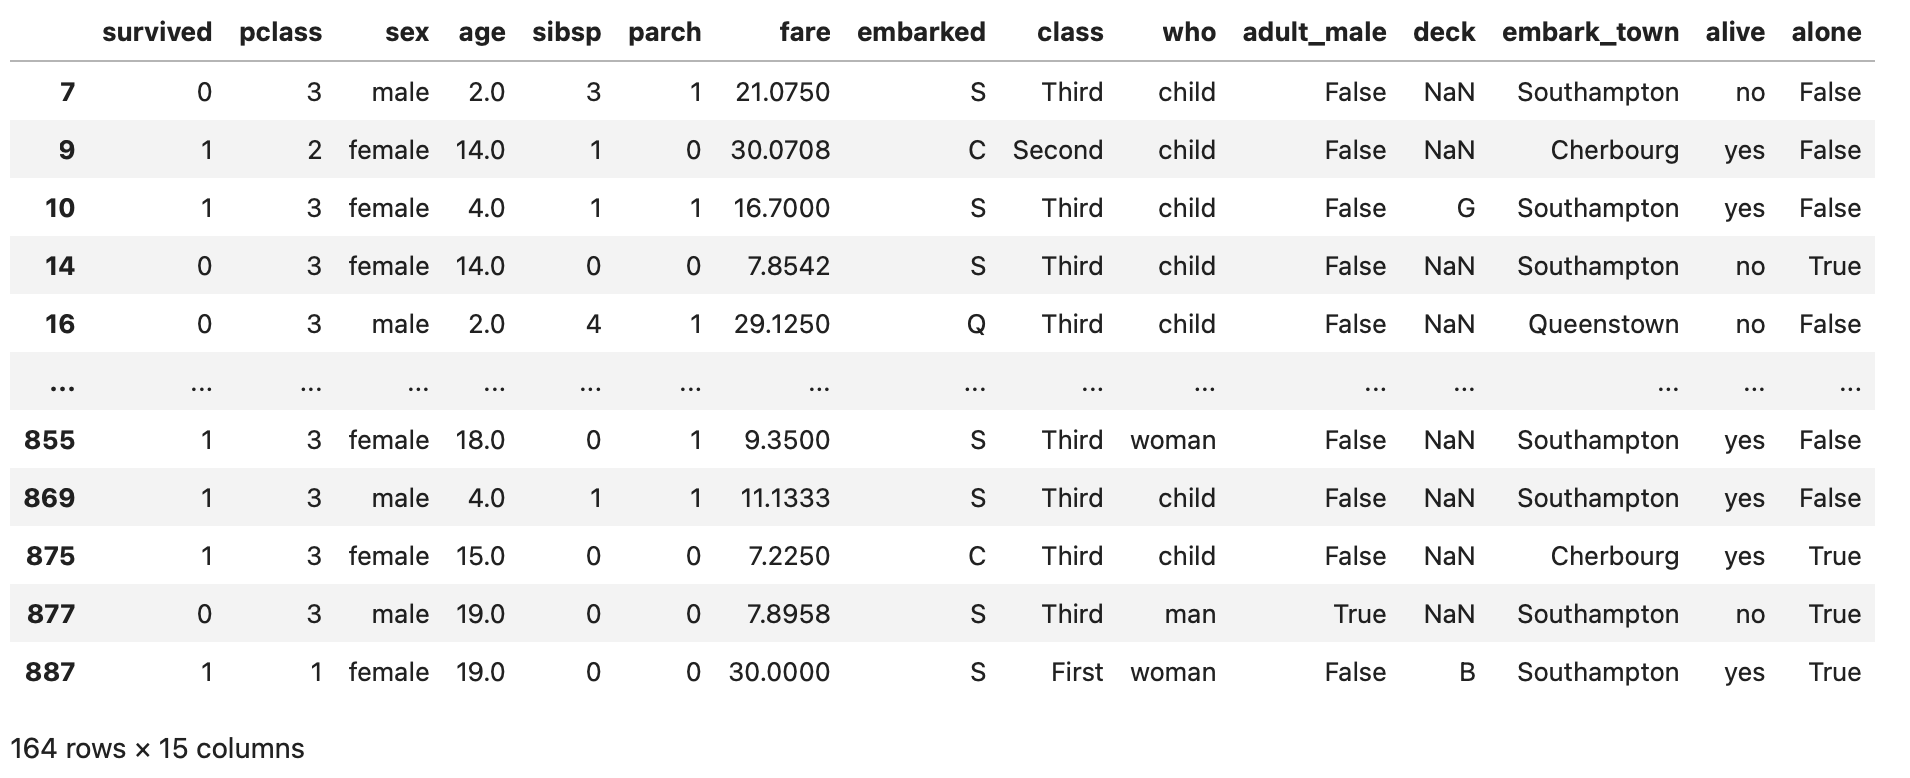

### survived 열을 통해 생존자(숫자 1) 행만 추출하기

In [67]:
df = data[data['survived']==1]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


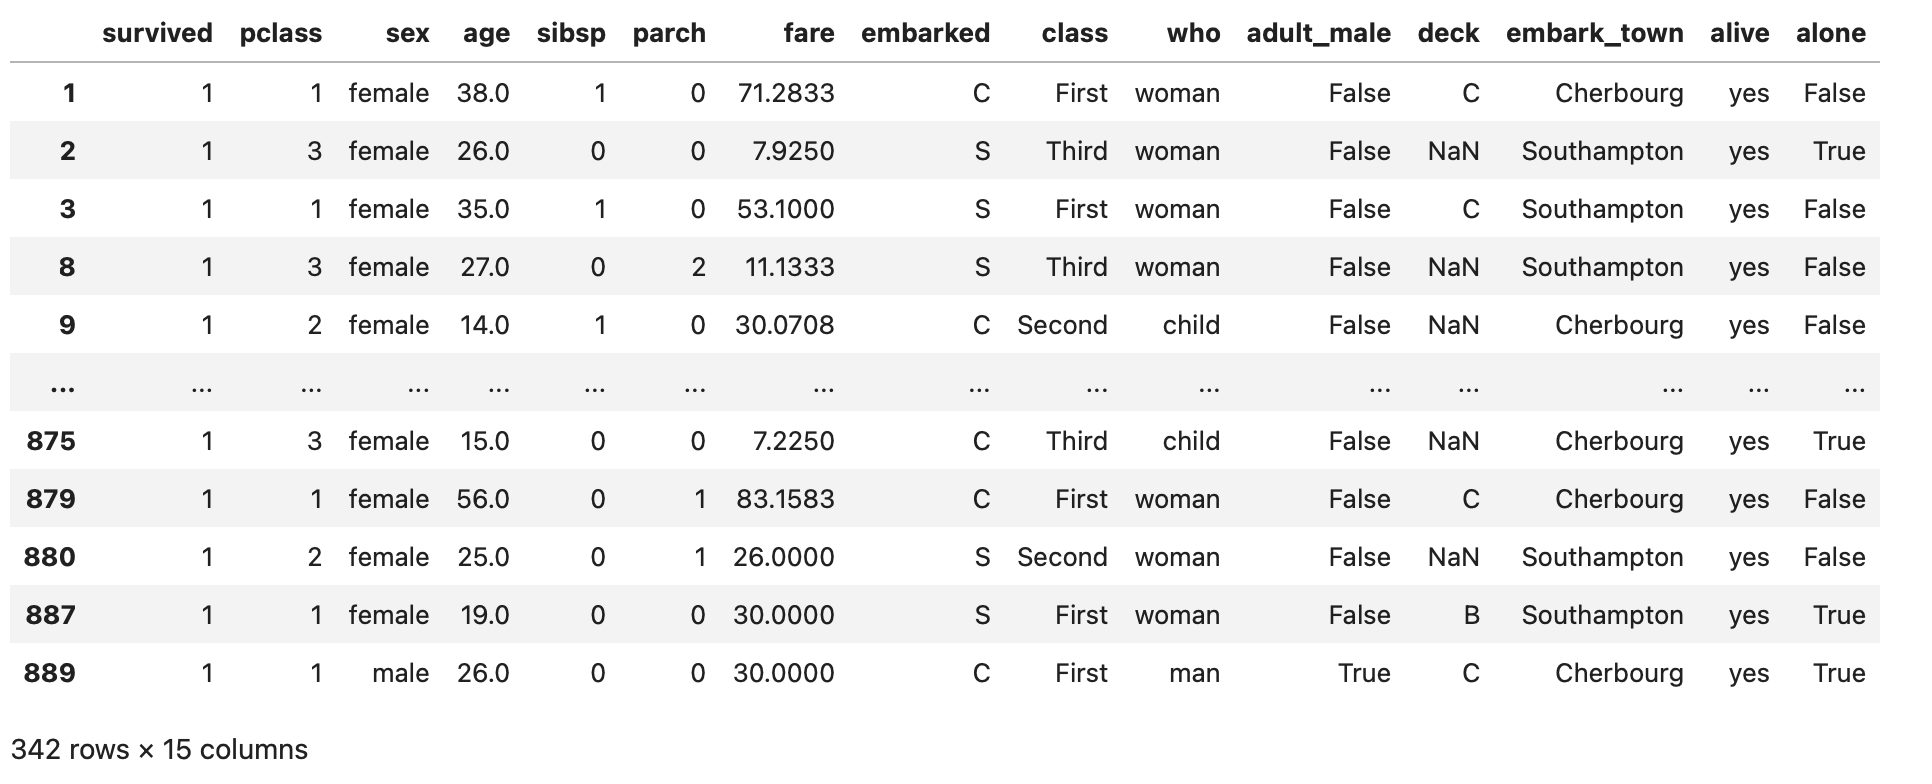

### 참고) loc에서 불리언 인덱싱 사용하기

loc을 사용해 'survived'열의 값이 1인 데이터를 추출하세요! (데이터프레임.loc[조건문, 열 이름] 형태 사용)

In [68]:
df = data.loc[data['survived']==1, 'survived']
df

1      1
2      1
3      1
8      1
9      1
      ..
875    1
879    1
880    1
887    1
889    1
Name: survived, Length: 342, dtype: int64

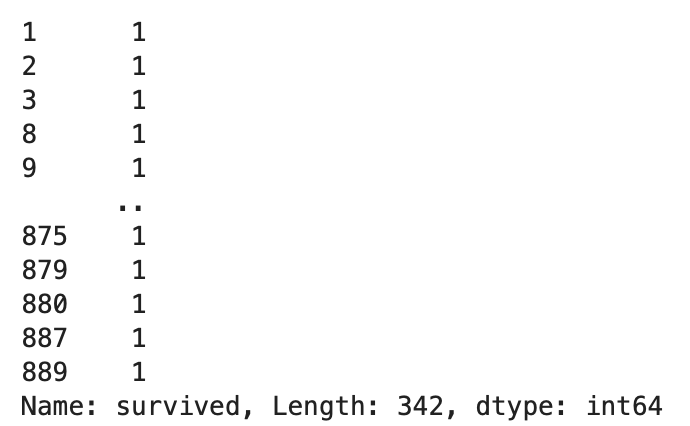

## df[(조건문 1) 논리연산자 (조건문 2)]
### 나이가 20세 이상이면서 성별이 여성인 탑승자 행을 추출하세요

In [70]:
#불리언인덱싱에서 조건문을 이어주는 논리 연산자는 문자가 아닌 기호로 사용해야합니다.
#and가 필요하다면 &, or이 필요하다면 |(엔터 위 역슬래시, 혹은 원화 기호를 시프트 누르고 입력)를 입력하세요
df = data[(data['age']>=20) & (data['sex']=='female')]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True


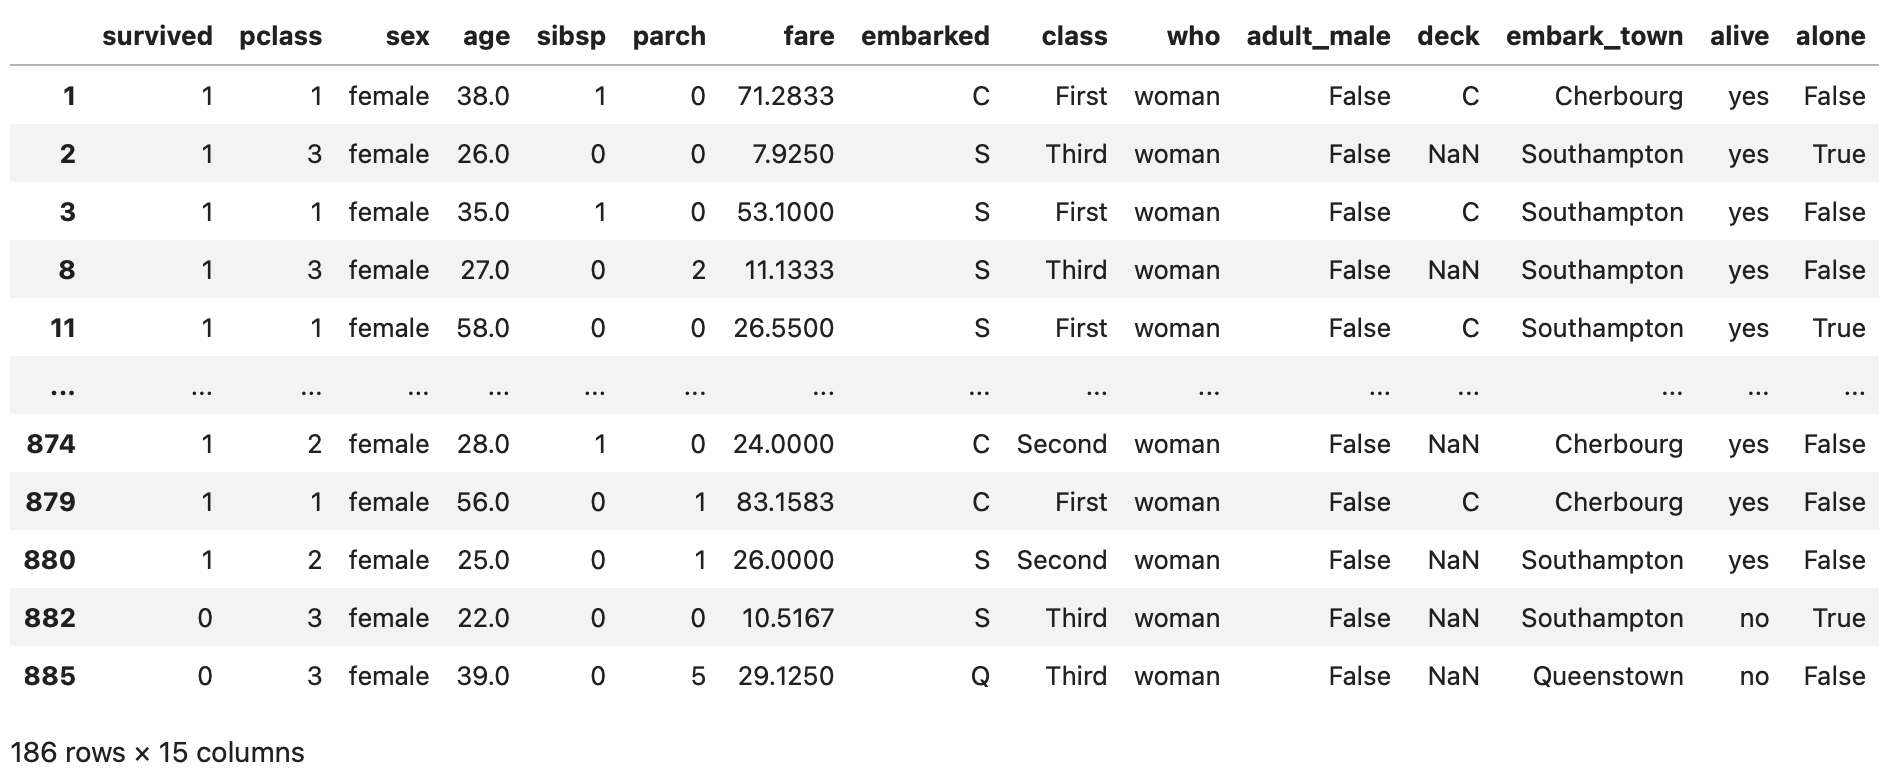

### sibsp의 값이 0이 아니거나, 또는 parch의 값이 0이 아닌 행을 추출하세요 (or 사용)

In [71]:
# a와 b가 같지 않다는 파이선에서 a != b 의 형태로 사용합니다!
df = data[(data['sibsp']!=0)|(data['parch']!=0)]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False


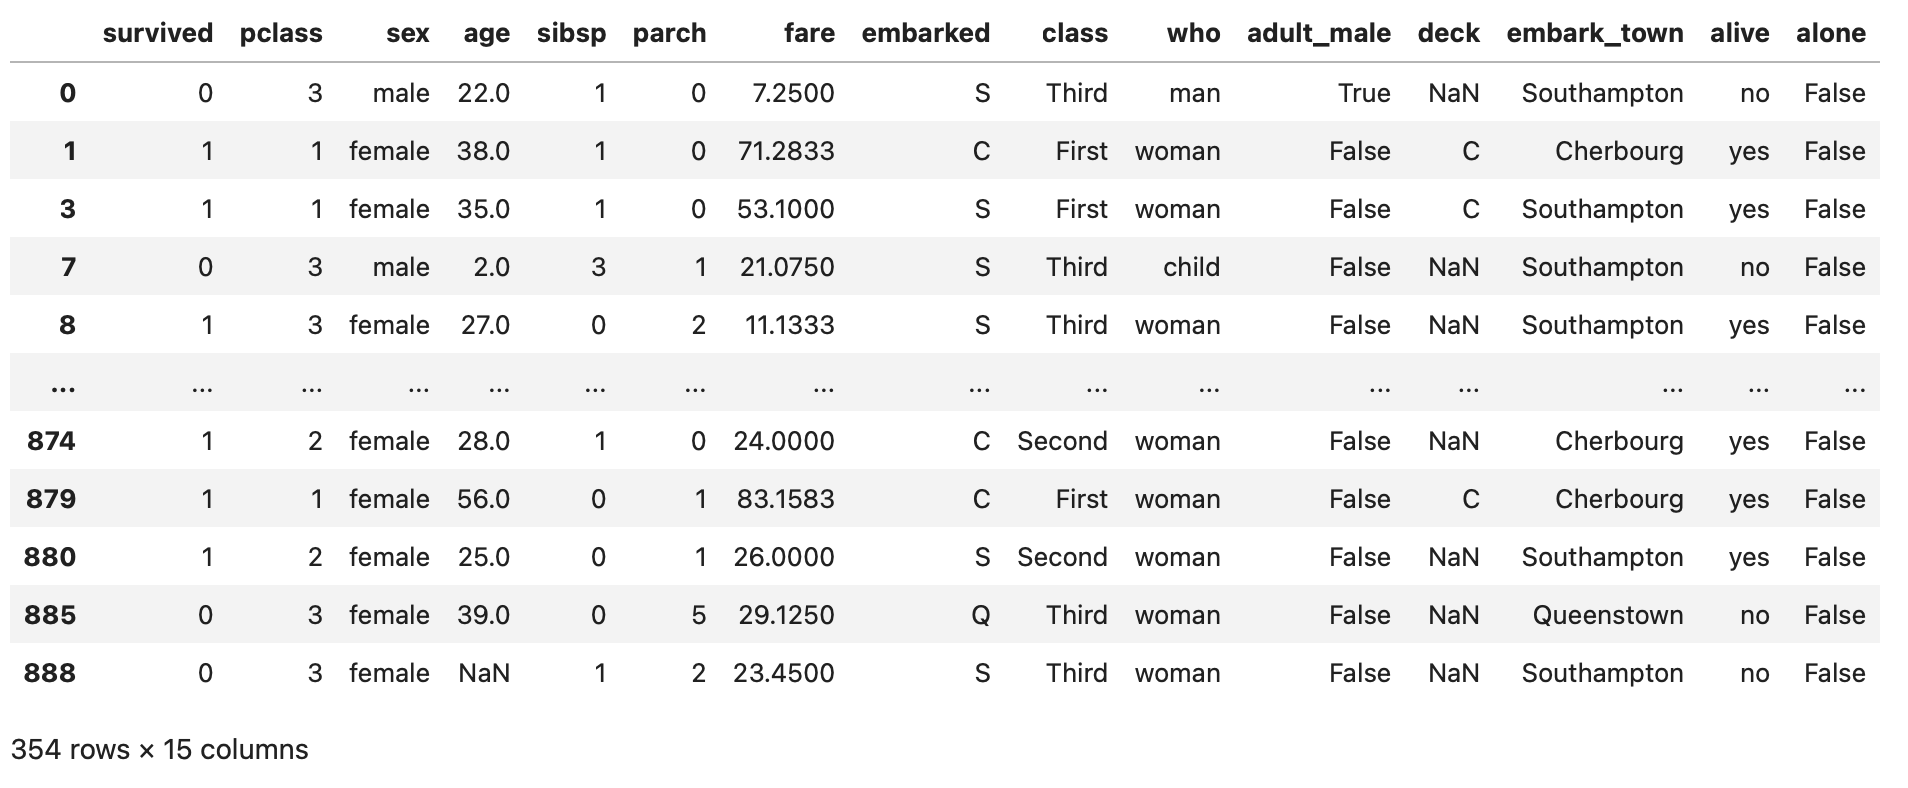

### sibsp의 값이 0이면서, parch의 값도 0인 행을 추출하세요 (and 사용)

In [72]:
df = data[(data['sibsp']==0)&(data['parch']==0)]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


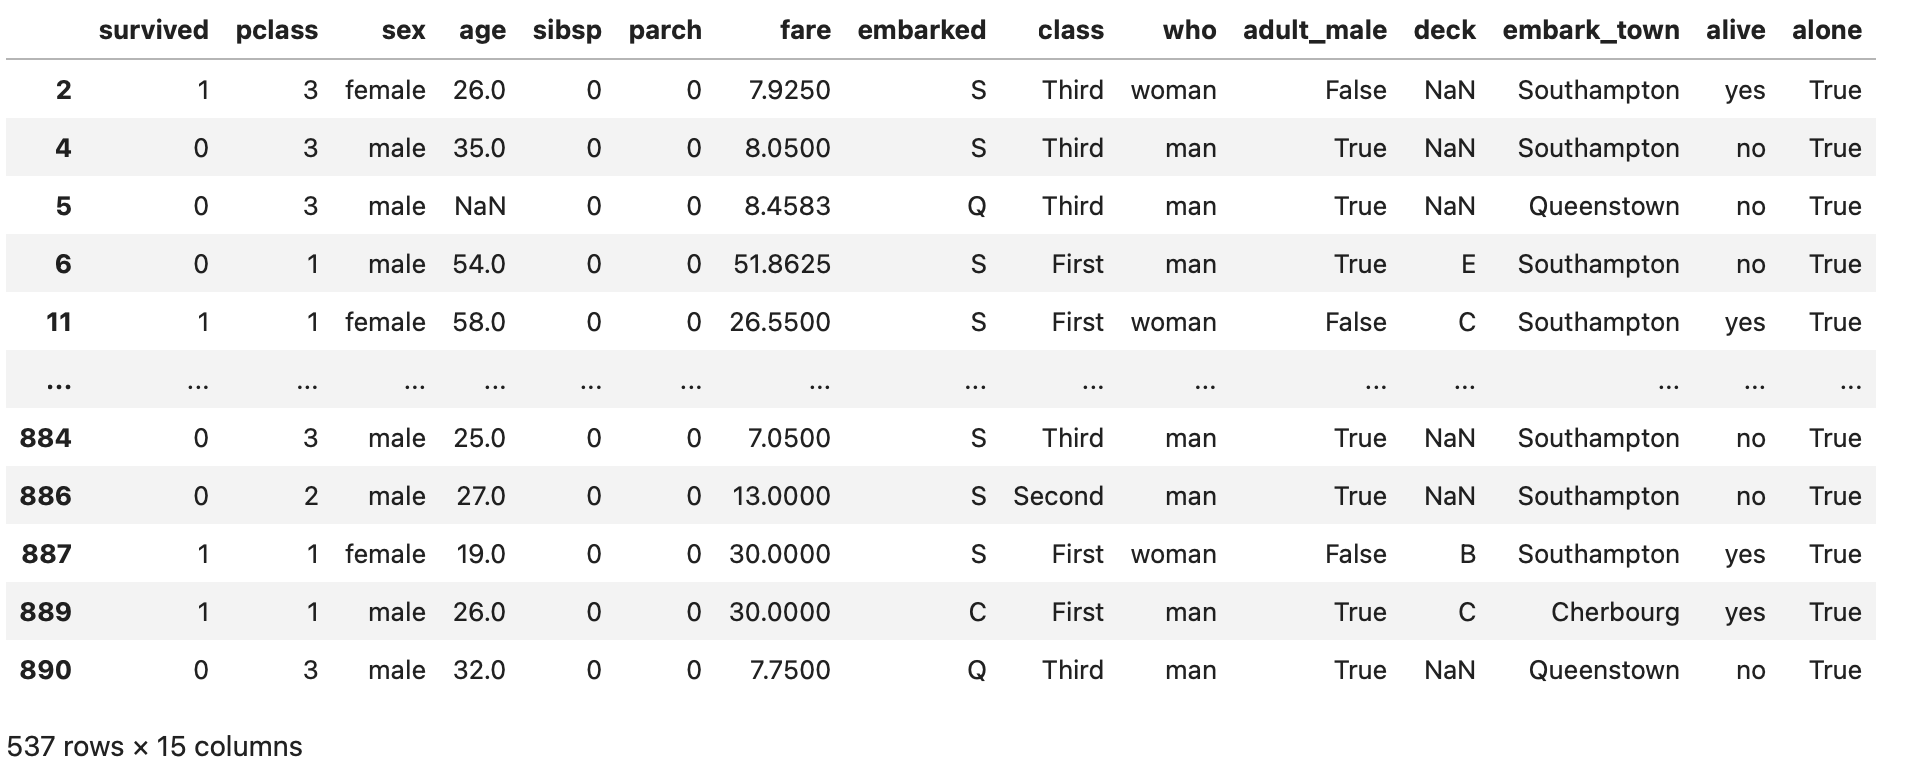

### 생존자이면서, 성별은 남성, 나이는 20세 이상인 행을 추출하세요

In [73]:
df = data[(data['survived']==1)&(data['sex']=='male')&(data['age']>=20)]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
21,1,2,male,34.0,0,0,13.0000,S,Second,man,True,D,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
74,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
81,1,3,male,29.0,0,0,9.5000,S,Third,man,True,NaN,Southampton,yes,True
97,1,1,male,23.0,0,1,63.3583,C,First,man,True,D,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
804,1,3,male,27.0,0,0,6.9750,S,Third,man,True,NaN,Southampton,yes,True
821,1,3,male,27.0,0,0,8.6625,S,Third,man,True,NaN,Southampton,yes,True
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
857,1,1,male,51.0,0,0,26.5500,S,First,man,True,E,Southampton,yes,True


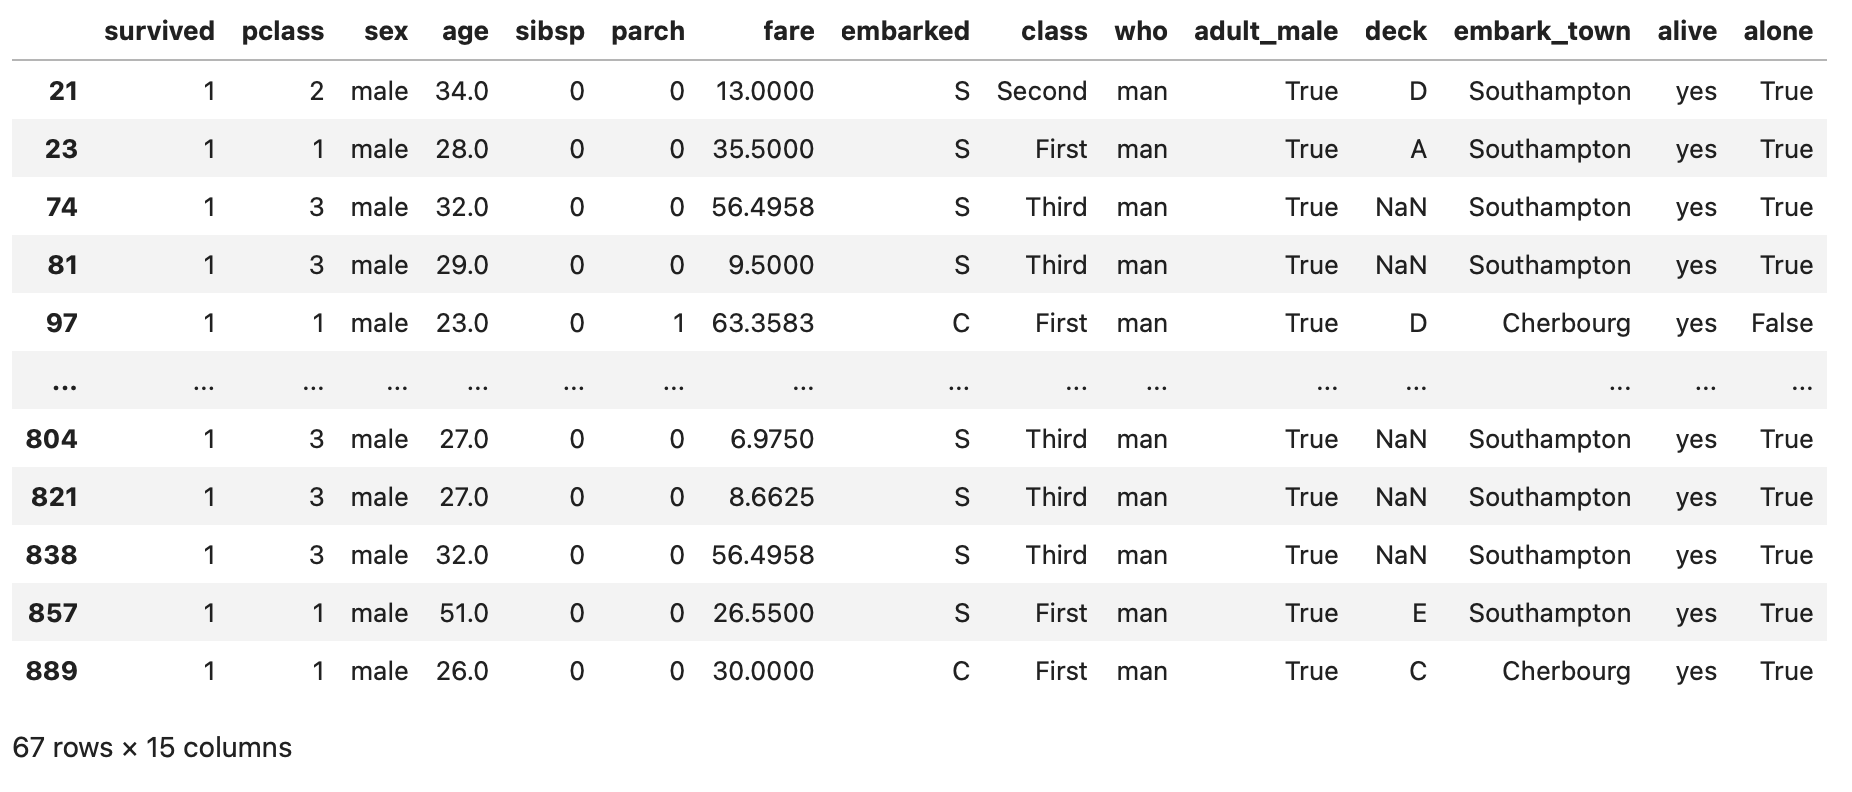

### 생존자이면서, 나이는 5세 미만이거나 70세 이상, 1등석 또는 2등석 탑승자인 행을 추출하세요.
- 단, 좌석 등급은 pclass 칼럼 기준이며, 3등석이 아닌 행을 구하지 말고, 1등석 or 2등석으로 구해주세요(결측치가 있을 수 있으니까요)
- 문제의 쉼표 단위로 괄호로 묶어서 작성해주세요. 아래 예시처럼요!

df = data[(생존자 조건)
          & (숭객 나이 조건 (or 구문)) 
          & (좌석 등급 조건 (or 구문))]


(& 대신 *을 사용해도 됩니다!)

In [74]:
df = data[(data['survived']==1)&((data['age']<5)|(data['age']>=70))&((data['pclass']==1)|(data['pclass']==2))]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
43,1,2,female,3.00,1,2,41.5792,C,Second,child,False,NaN,Cherbourg,yes,False
78,1,2,male,0.83,0,2,29.0000,S,Second,child,False,NaN,Southampton,yes,False
183,1,2,male,1.00,2,1,39.0000,S,Second,child,False,F,Southampton,yes,False
193,1,2,male,3.00,1,1,26.0000,S,Second,child,False,F,Southampton,yes,False
305,1,1,male,0.92,1,2,151.5500,S,First,child,False,C,Southampton,yes,False
340,1,2,male,2.00,1,1,26.0000,S,Second,child,False,F,Southampton,yes,False
407,1,2,male,3.00,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False
445,1,1,male,4.00,0,2,81.8583,S,First,child,False,A,Southampton,yes,False
530,1,2,female,2.00,1,1,26.0000,S,Second,child,False,NaN,Southampton,yes,False
618,1,2,female,4.00,2,1,39.0000,S,Second,child,False,F,Southampton,yes,False


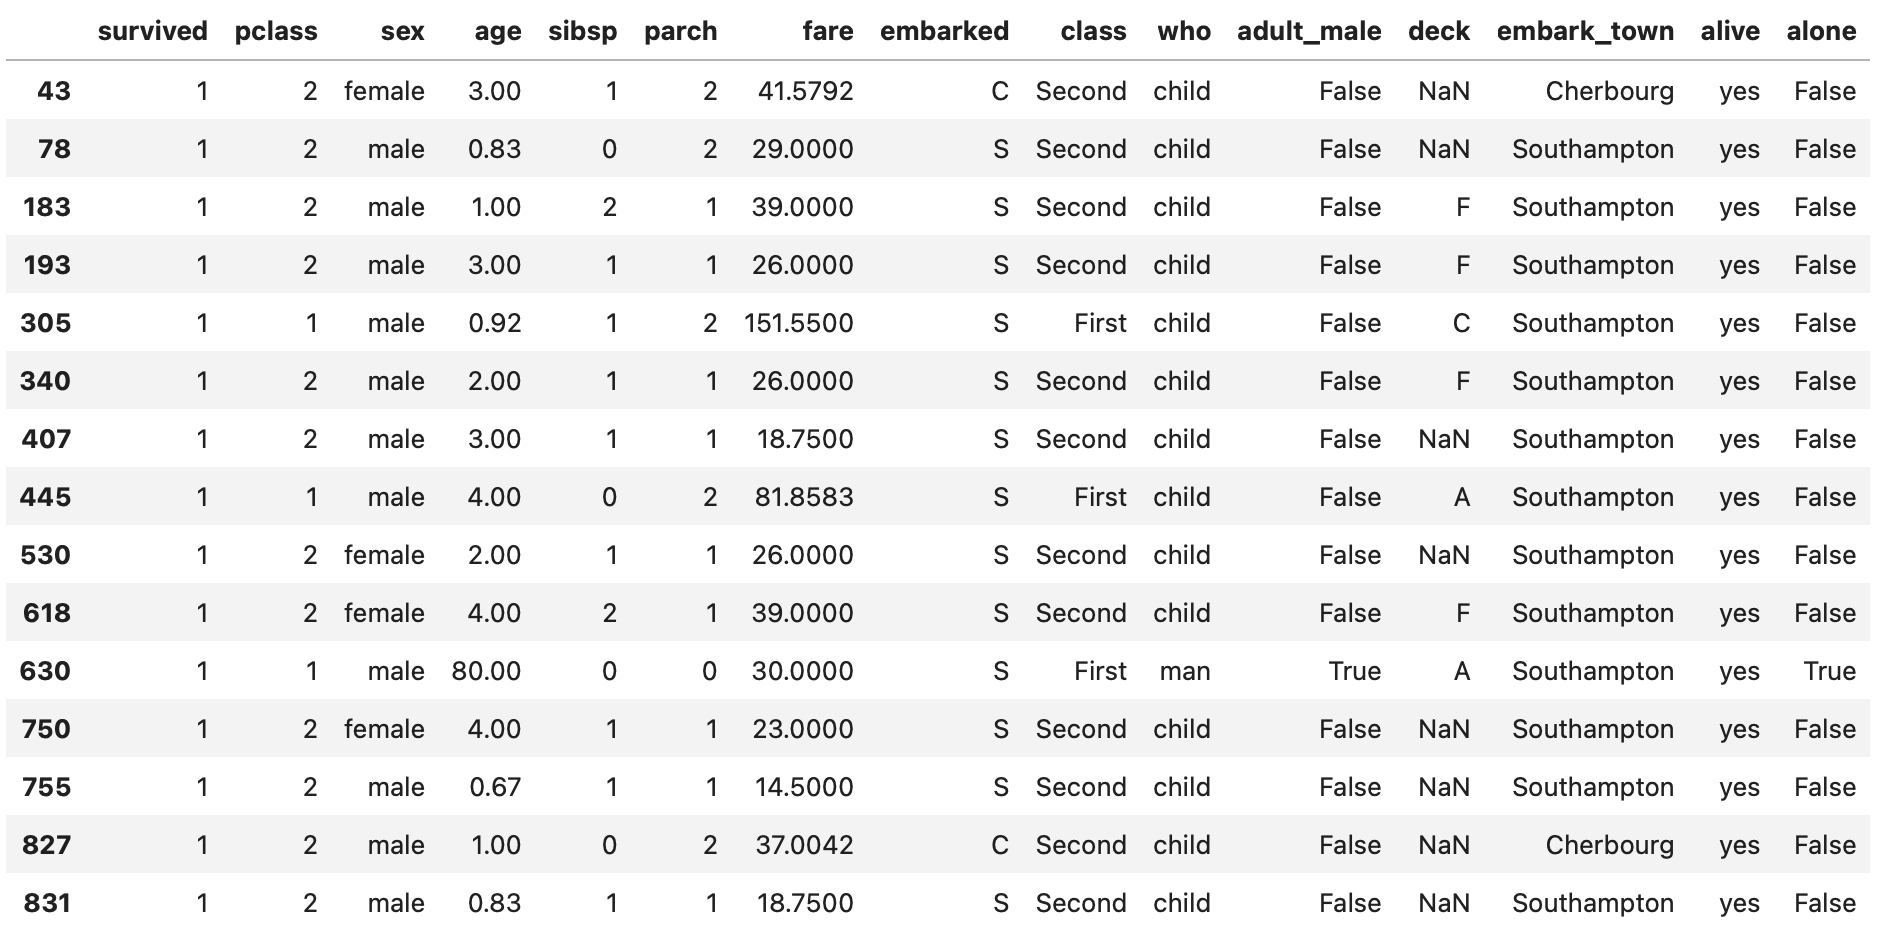

# 인덱스 설정

### set_index를 사용해 age 열을 인덱스로 사용해봅시다. df1에 대해 inpace=True 옵션을 사용해주세요!

In [76]:
df1 = data[:] #원본 데이터프레임을 유지하기 위해 새로운 데이터프레임에 내용을 복사하는 구문입니다. 
df1.set_index('age', inplace=True)
df1

,survived,pclass,sex,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
age,,,,,,,,,,,,,,
22.0,0,3,male,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
38.0,1,1,female,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
26.0,1,3,female,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
35.0,1,1,female,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
35.0,0,3,male,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27.0,0,2,male,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
19.0,1,1,female,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
NaN,0,3,female,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


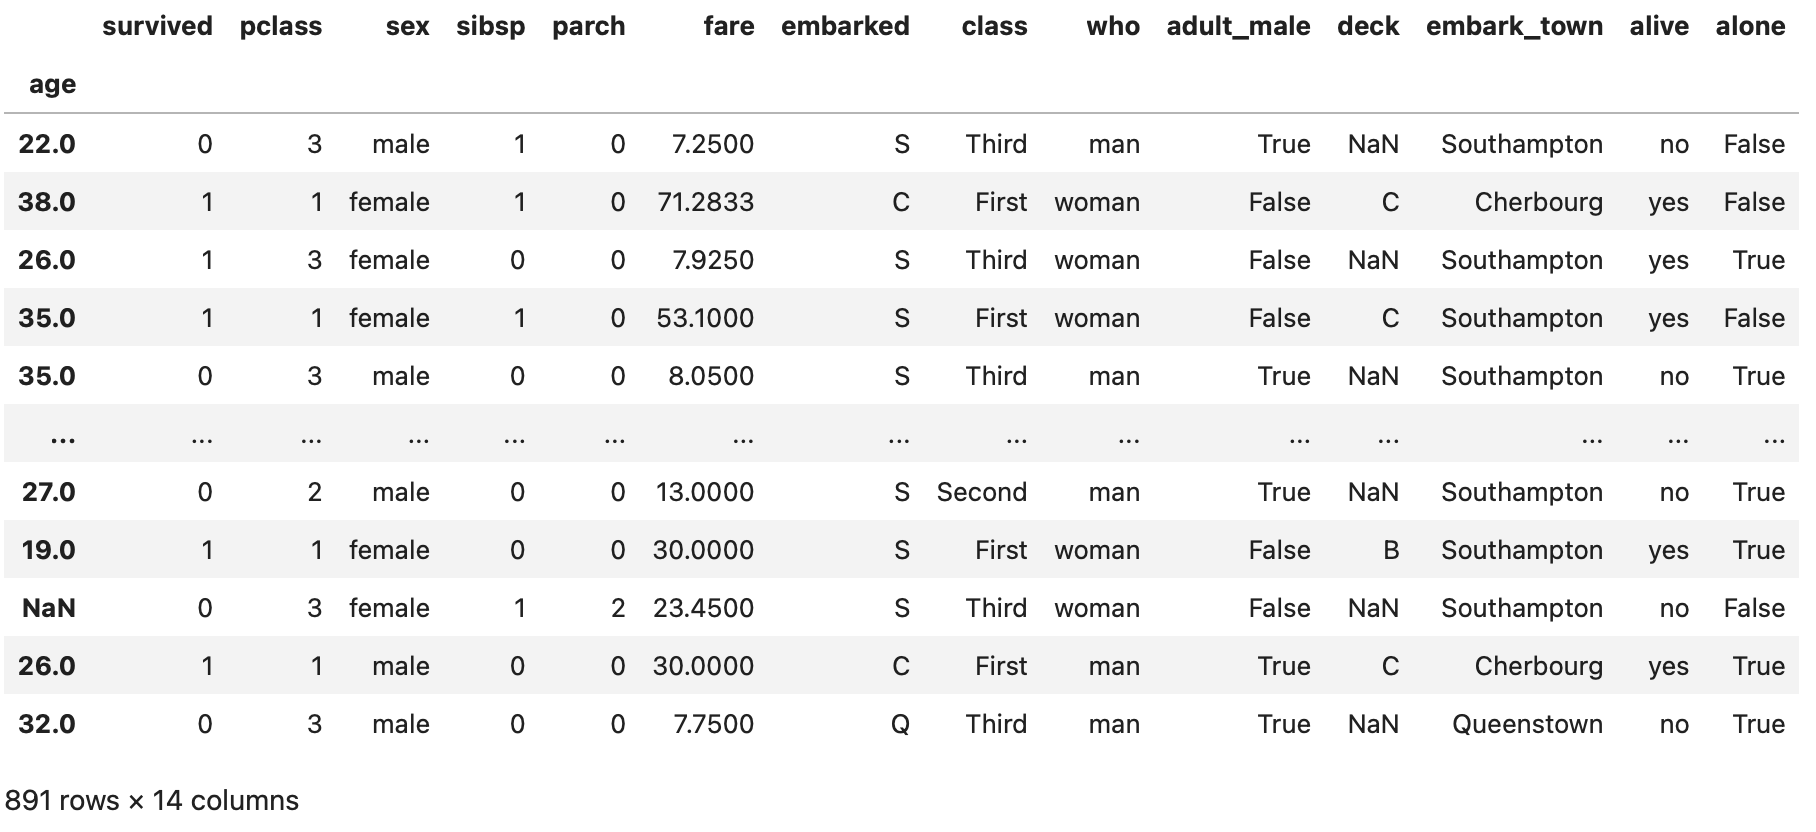

### sort_index를 사용해서 나이 인덱스 기준으로 정렬하기


In [79]:
df1.sort_index(ascending=True)

,survived,pclass,sex,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
age,,,,,,,,,,,,,,
0.42,1,3,male,0,1,8.5167,C,Third,child,False,NaN,Cherbourg,yes,False
0.67,1,2,male,1,1,14.5000,S,Second,child,False,NaN,Southampton,yes,False
0.75,1,3,female,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
0.75,1,3,female,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
0.83,1,2,male,0,2,29.0000,S,Second,child,False,NaN,Southampton,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,0,3,male,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
NaN,0,3,female,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False
NaN,0,3,male,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True


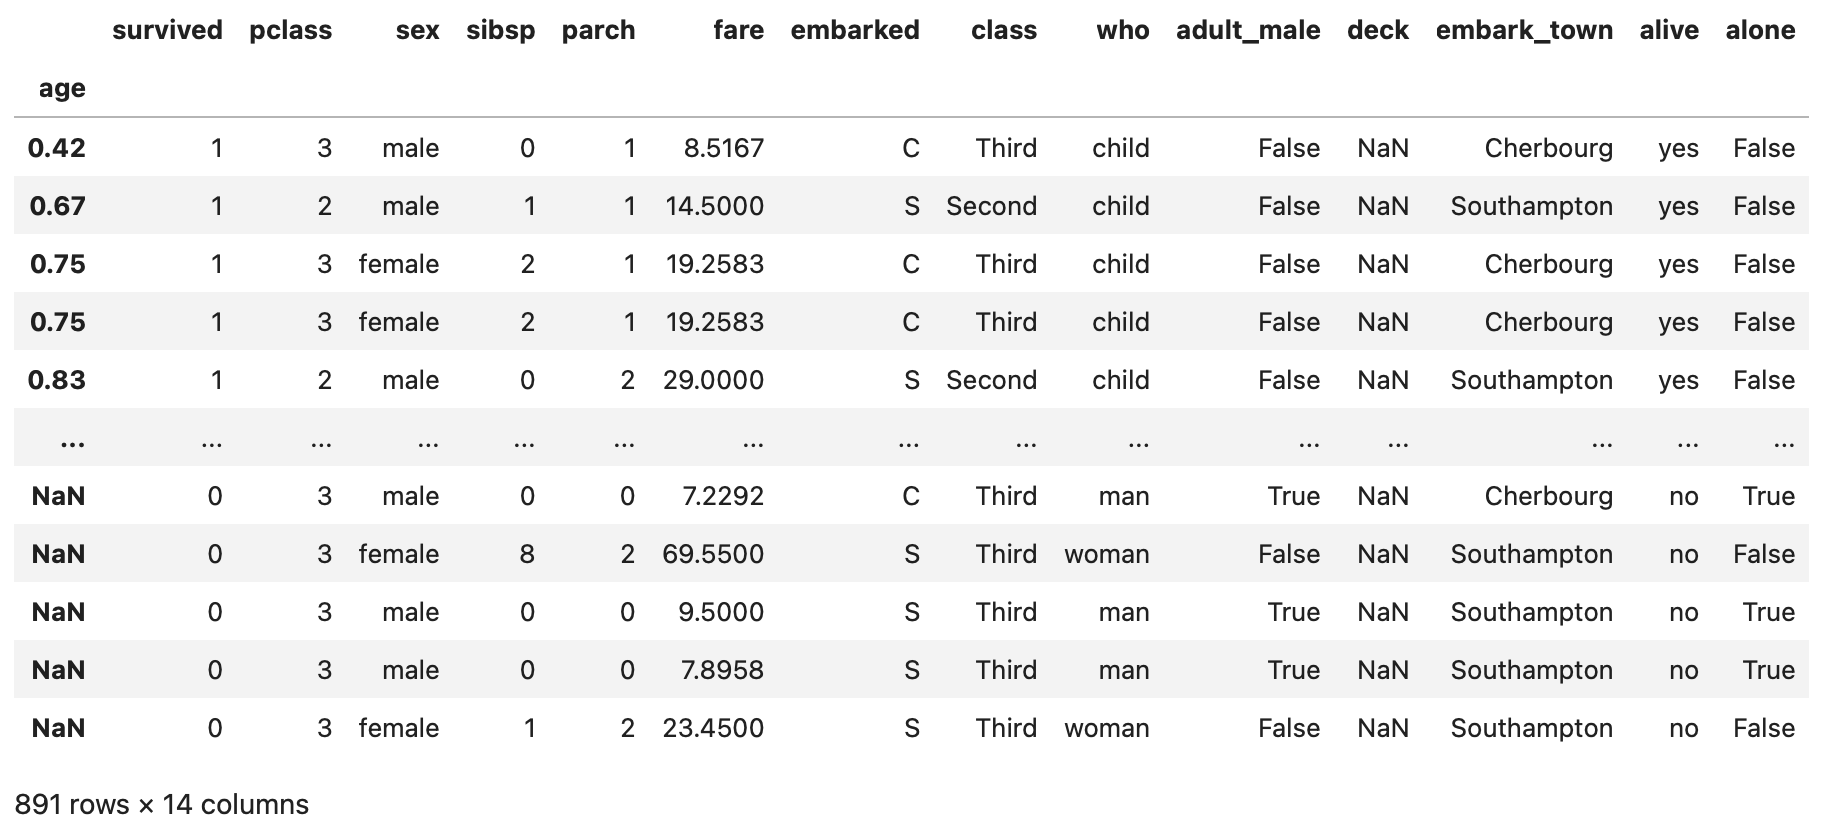

### reset_index를 활용해 인덱스를 리셋합니다. inplace=True, drop=False 옵션 사용해주세요

In [80]:
df1.reset_index(inplace=True, drop=False)
df1

,age,survived,pclass,sex,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,22.0,0,3,male,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,38.0,1,1,female,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,26.0,1,3,female,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,35.0,1,1,female,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,35.0,0,3,male,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.0,0,2,male,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,19.0,1,1,female,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,NaN,0,3,female,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,26.0,1,1,male,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


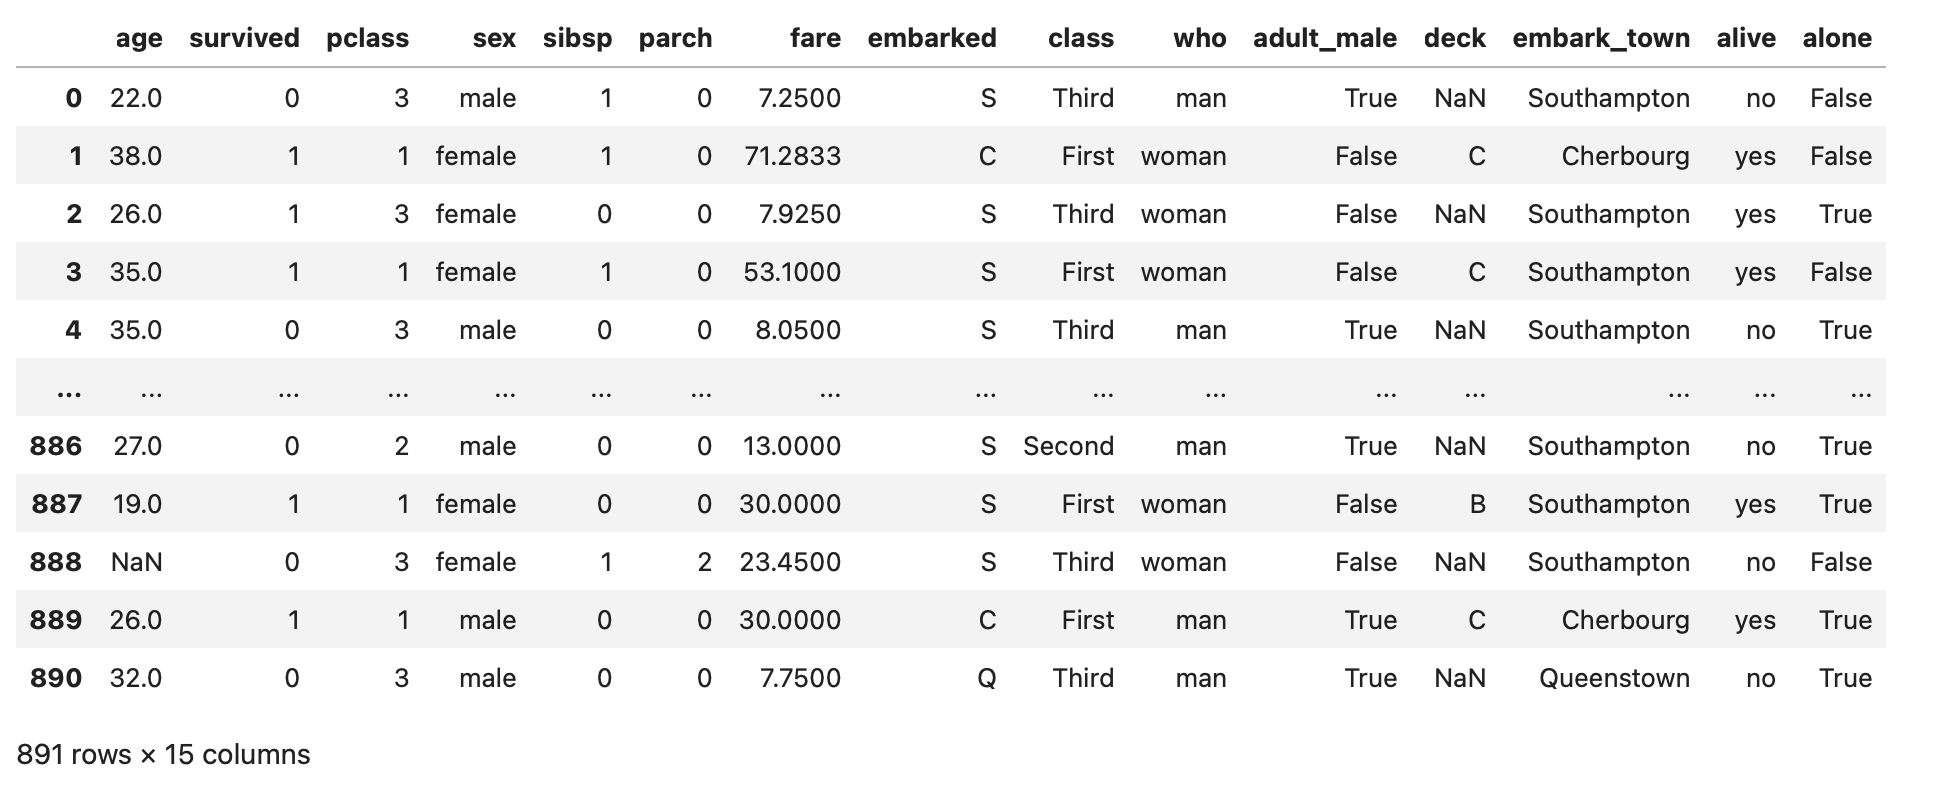

### 나이를 기준으로 다시 정렬을 해봅시다

In [81]:
df1.sort_values(by ='age')

,age,survived,pclass,sex,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
803,0.42,1,3,male,0,1,8.5167,C,Third,child,False,NaN,Cherbourg,yes,False
755,0.67,1,2,male,1,1,14.5000,S,Second,child,False,NaN,Southampton,yes,False
644,0.75,1,3,female,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
469,0.75,1,3,female,2,1,19.2583,C,Third,child,False,NaN,Cherbourg,yes,False
78,0.83,1,2,male,0,2,29.0000,S,Second,child,False,NaN,Southampton,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,NaN,0,3,male,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
863,NaN,0,3,female,8,2,69.5500,S,Third,woman,False,NaN,Southampton,no,False
868,NaN,0,3,male,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True
878,NaN,0,3,male,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True


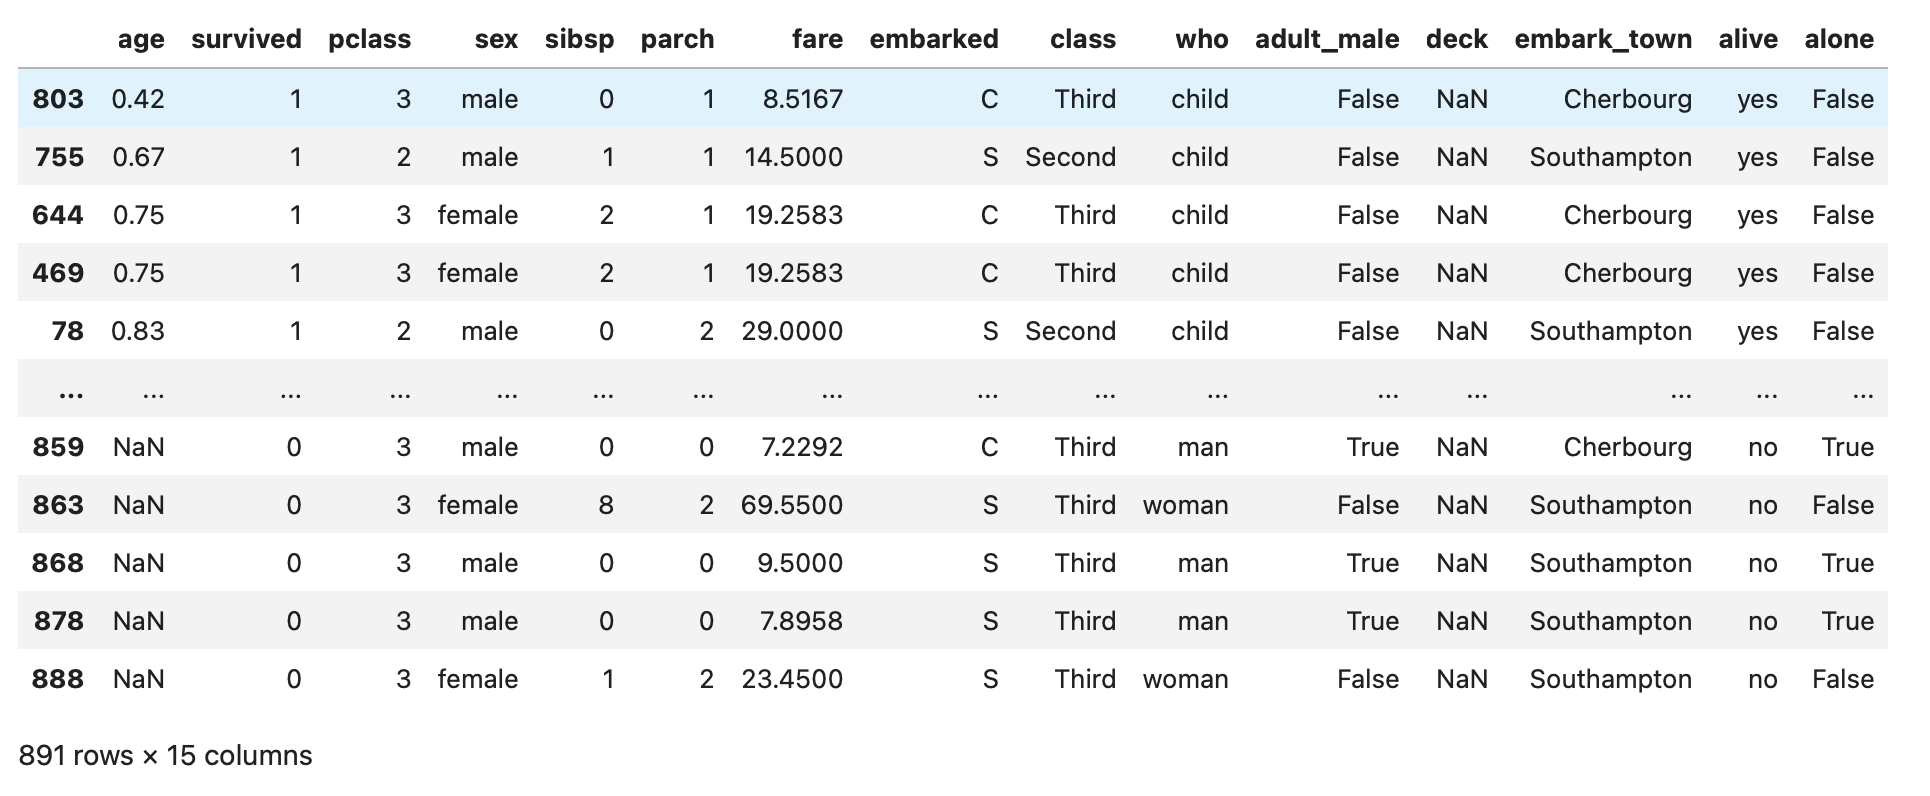

### 열 순서 변경(참고 수준으로 보세요~~)

In [82]:
columns = list(data.columns.values)
print(columns, '\n')

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'] 



컬럼이 많으니 몇개로만 추려서...

In [83]:
data4 = data.loc[0:5, "survived":"age"]
# 다시 설정
columns = list(data4.columns.values)
print(columns, '\n')

['survived', 'pclass', 'sex', 'age'] 



열이름이 알파벳 순서로 정렬되는 것을 확인

In [84]:
columns_sorted = sorted(columns)
data_sorted = data4[columns_sorted]
data_sorted

,age,pclass,sex,survived
0,22.0,3,male,0
1,38.0,1,female,1
2,26.0,3,female,1
3,35.0,1,female,1
4,35.0,3,male,0
5,NaN,3,male,0


columns에 대한 역순

In [85]:
columns_reversed = list(reversed(columns))
data_reversed = data4[columns_reversed]
data_reversed

,age,sex,pclass,survived
0,22.0,male,3,0
1,38.0,female,1,1
2,26.0,female,3,1
3,35.0,female,1,1
4,35.0,male,3,0
5,NaN,male,3,0


원하는 순서

In [86]:
columns_customed = ["pclass", "sex", "age", "survived"]
data_customed = data4[columns_customed]
data_customed

,pclass,sex,age,survived
0,3,male,22.0,0
1,1,female,38.0,1
2,3,female,26.0,1
3,1,female,35.0,1
4,3,male,35.0,0
5,3,male,NaN,0


지금까지는 컬럼 순서를 바꿀 때마다 값들도 같이 따라 움직였죠? 그렇다면 값들은 그대로 두고 컬럼명만 바꾸고 싶을 땐 어떻게 해야 할까요?

In [87]:
data4.columns = ['pclass','age','gender','weight'] # 인덱스 바꿀 때 df.index = [~] 썼던거랑 비슷하죠?
data4


,pclass,age,gender,weight
0,0,3,male,22.0
1,1,1,female,38.0
2,1,3,female,26.0
3,1,1,female,35.0
4,0,3,male,35.0
5,0,3,male,NaN


# 데이터 조작
## 데이터 추가/삭제

### Age_0 이라는 컬럼 생성

In [88]:
data2 = data.copy() # 원본이 수정되는 것을 방지하기 위해 복사본 생성
data2["Age_0"] = 0 # 새로운 칼럼을 생성하고 전체 값을 0으로 초기화합니다
data2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_0
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


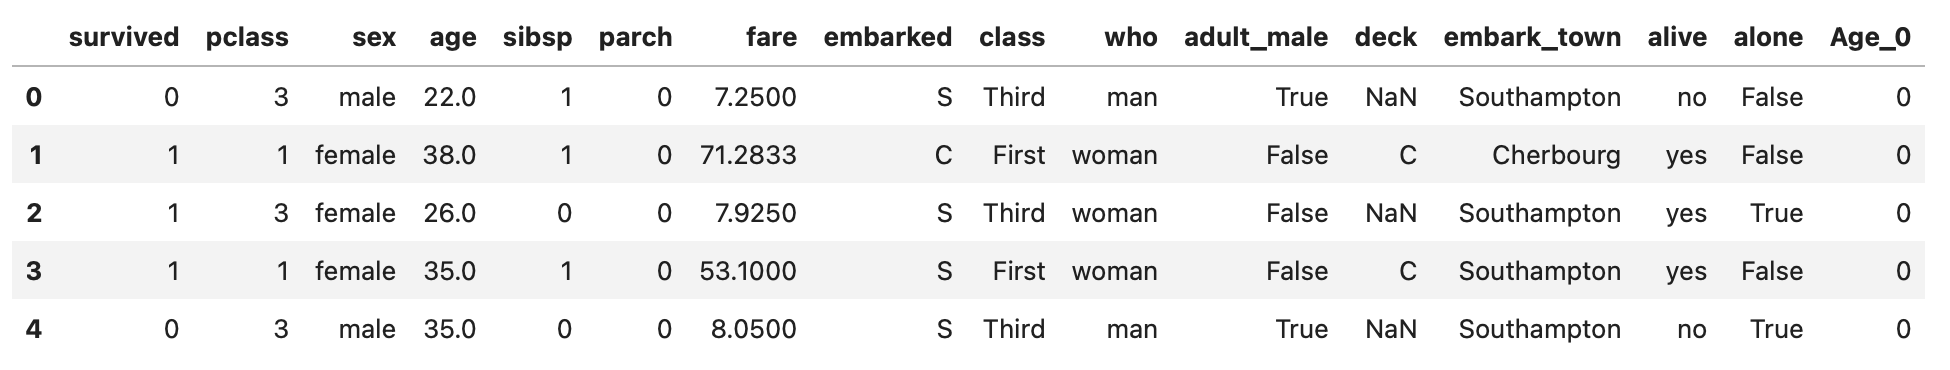

### 데이터프레임 연산

In [89]:
data2['Age_0'] = data2['Age_0'] + 100
data2.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_0
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,100
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,100
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,100
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,100
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,100


### 열을 삭제해주세요

In [90]:
# axis=*, inplace=True 옵션을 사용해주세요. 이 중 axis 옵션에 주의해주세요! 열을 삭제하려면 axis를 뭘 줘야 했죠?
data2.drop('Age_0', axis=1, inplace=True)
data2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


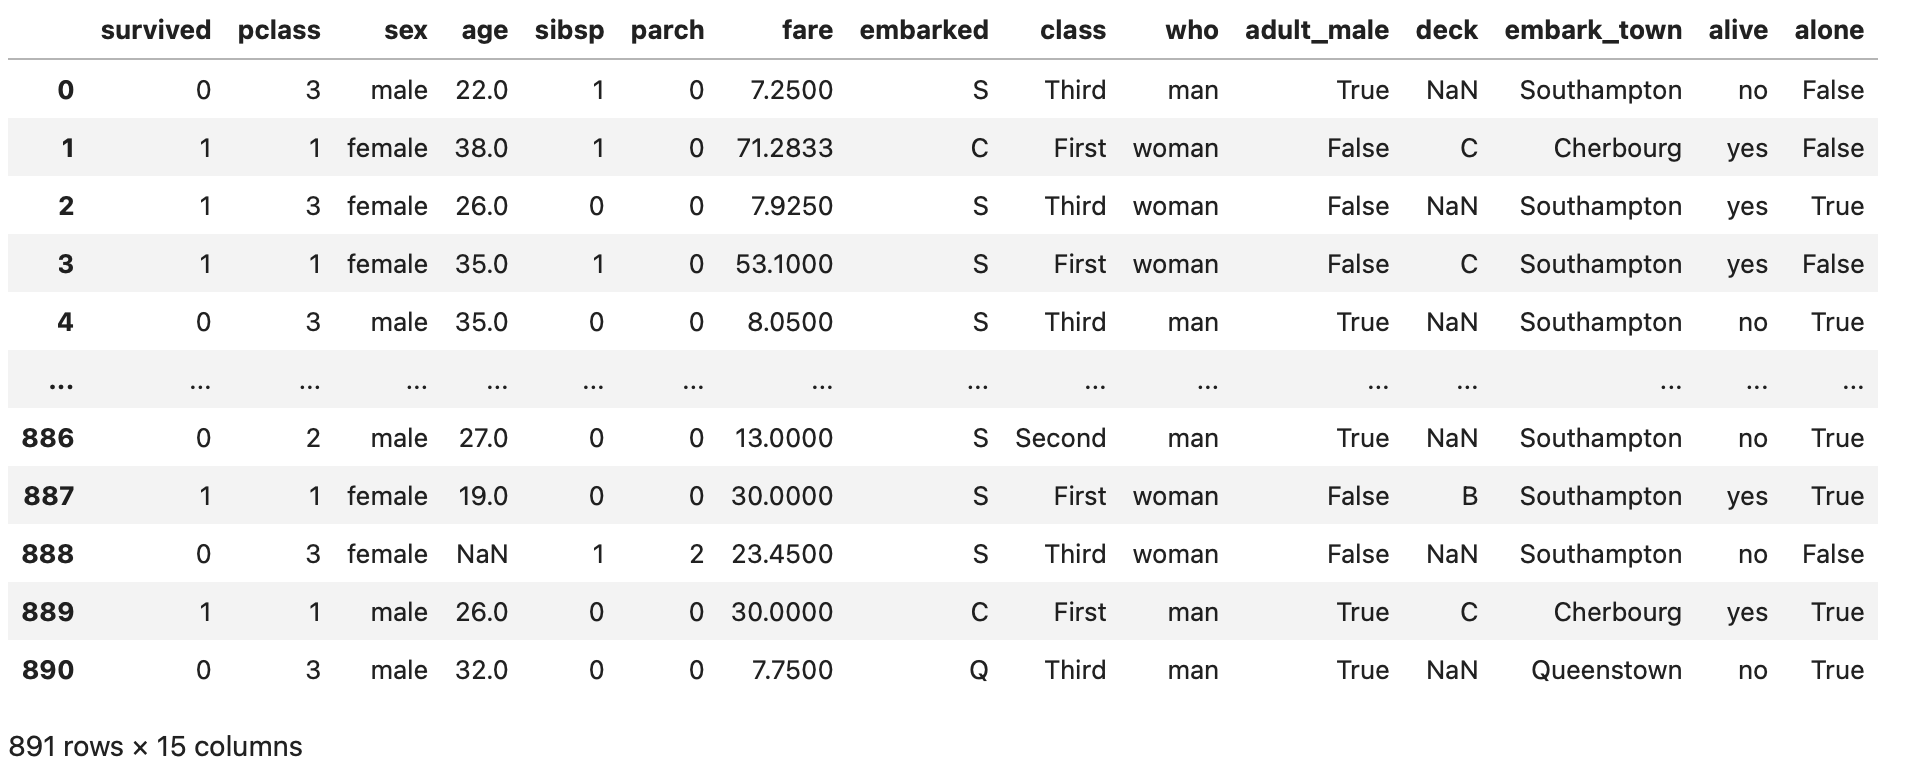

## 데이터 정렬

### 인덱스를 기준으로 데이터를 내림차순으로 정렬해주세요!

In [91]:
# ascending= 와 inplace=True 옵션을 사용해주세요
data2.sort_index(ascending=False, inplace=True)
data2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
890,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


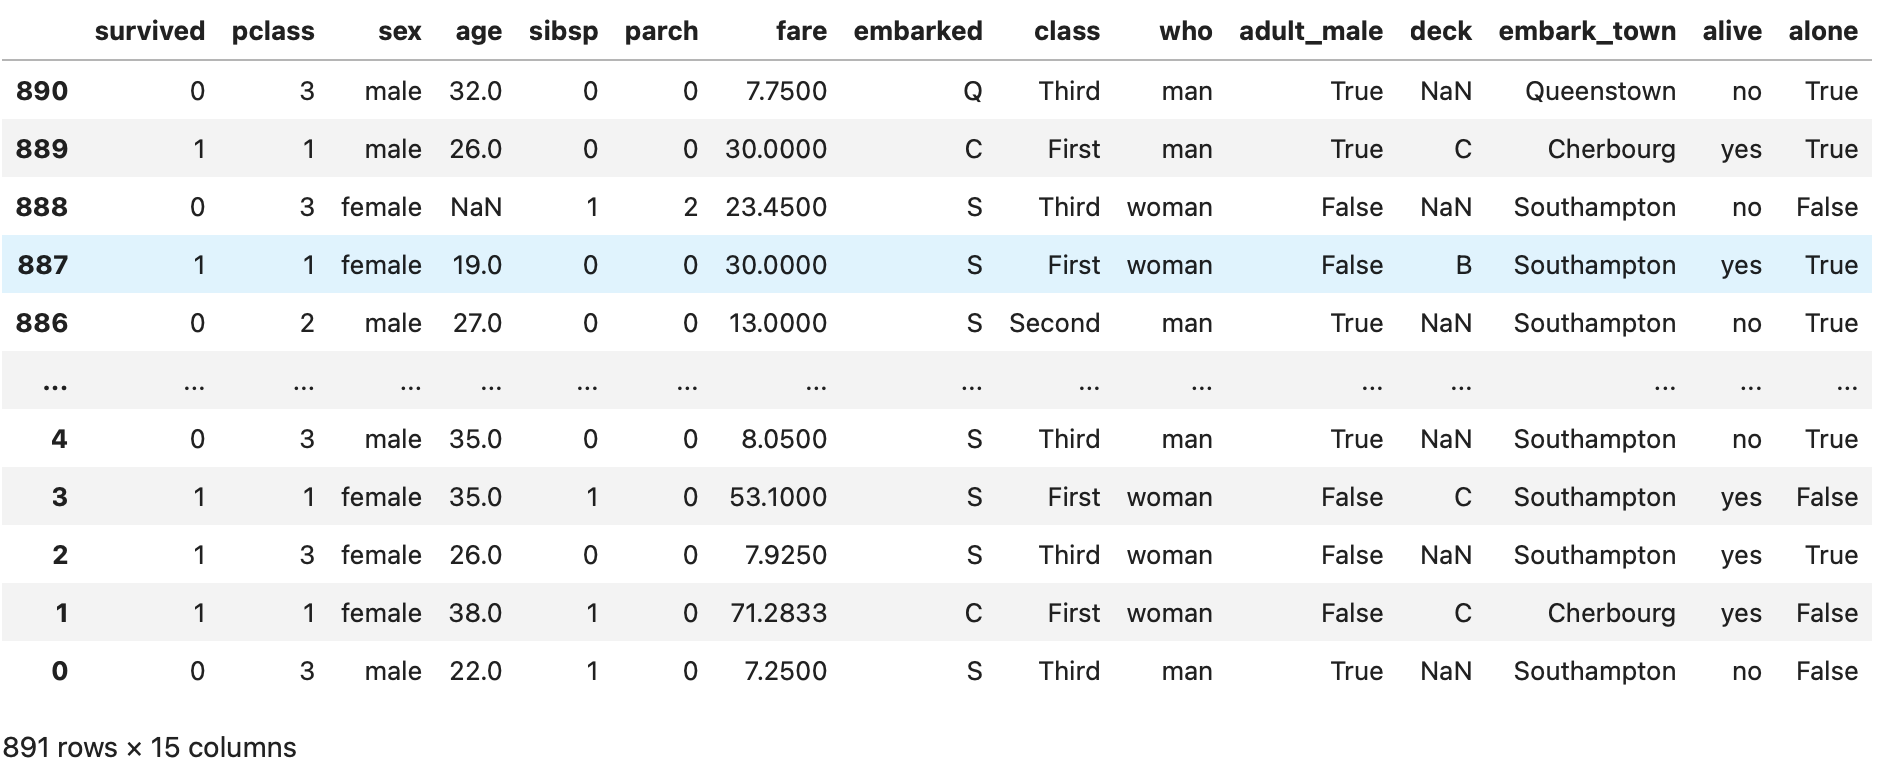

### 다시 원상복구를 시켜봅시다

In [93]:
data2.reset_index(drop=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,32.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
1,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
2,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
3,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
4,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
887,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
888,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
889,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


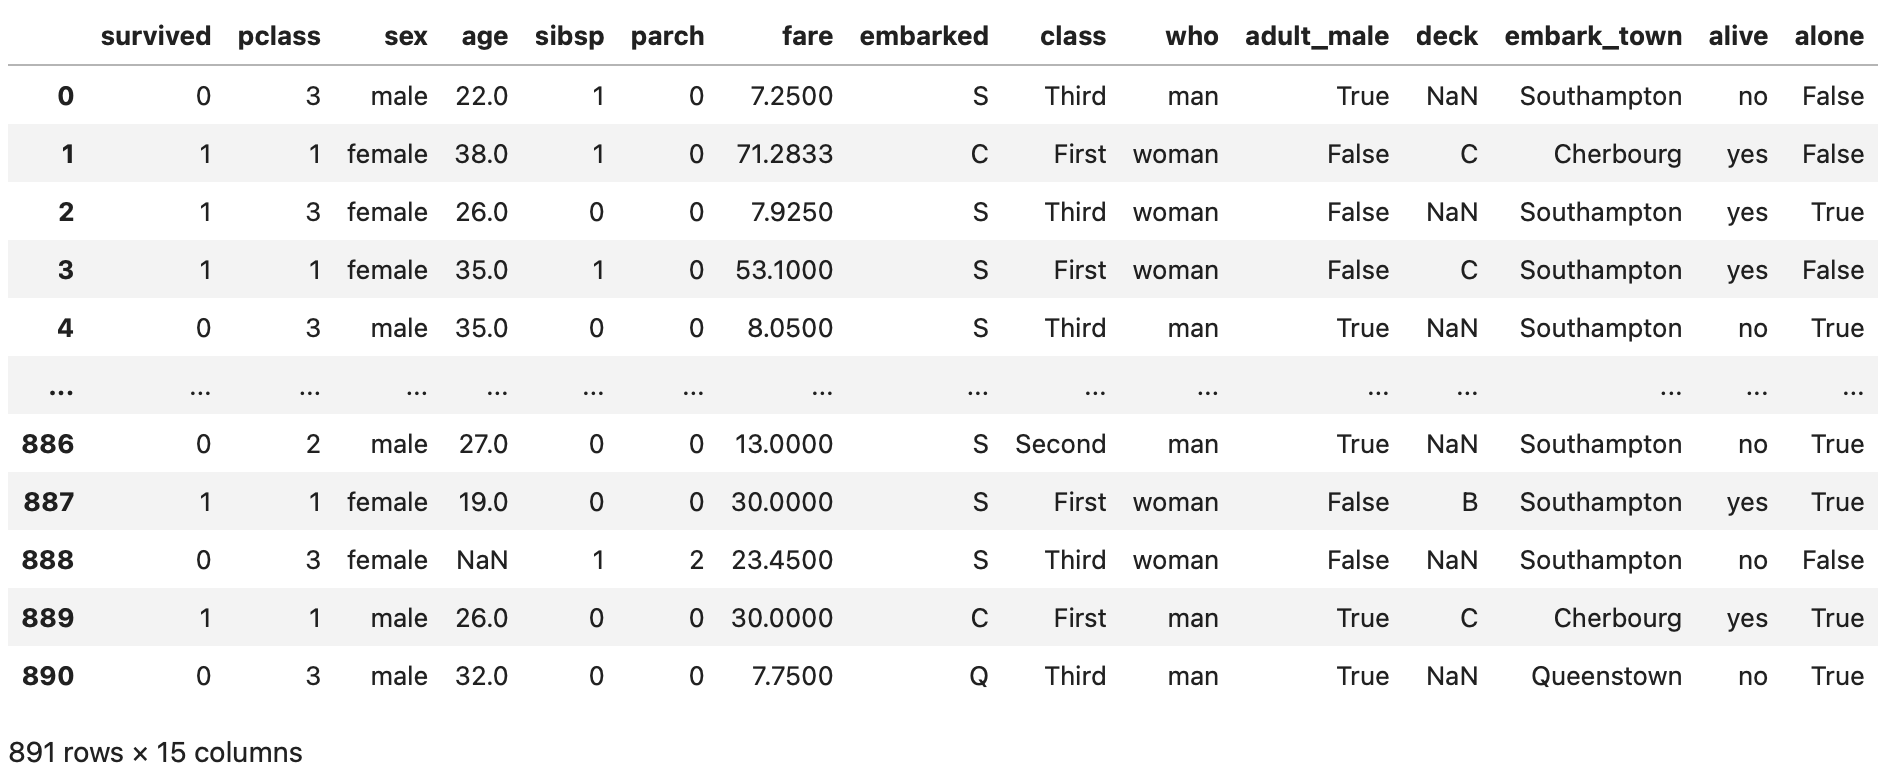

### embark_town을 기준으로 내림차순 정렬하고, 같은 값은 pclass를 기준으로 내림차순 정렬해주세요!

embark_town 열을 기준으로 내림차순을 하되, 만약 동일한 값이 있다면 그 부분에 대해서만 pclass 열을 따라 내림차순으로 정렬합니다.

In [94]:
# 여러 열을 기준으로 정렬을 할 때는, 리스트 형태로 인자를 전달해주면 됩니다!
titanic_sorted = data.sort_values(by=["embark_town","pclass"], ascending = [False, False])

titanic_sorted.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.250,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.925,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.050,S,Third,man,True,NaN,Southampton,no,True


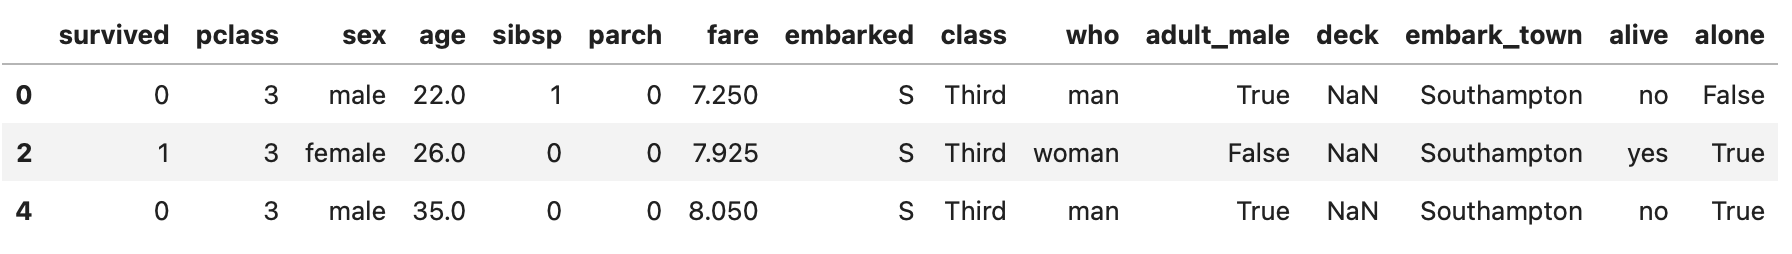

## 데이터프레임 병합
### concat을 사용해서 데이터프레임을 병합하는 연습을 진행해보아요

In [95]:
data3 = data.copy()
d1 = data3.iloc[0:100]
d2 = data3.iloc[700:800]
d1

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
97,1,1,male,23.0,0,1,63.3583,C,First,man,True,D,Cherbourg,yes,False
98,1,2,female,34.0,0,1,23.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [96]:
d2

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
700,1,1,female,18.0,1,0,227.5250,C,First,woman,False,C,Cherbourg,yes,False
701,1,1,male,35.0,0,0,26.2875,S,First,man,True,E,Southampton,yes,True
702,0,3,female,18.0,0,1,14.4542,C,Third,woman,False,NaN,Cherbourg,no,False
703,0,3,male,25.0,0,0,7.7417,Q,Third,man,True,NaN,Queenstown,no,True
704,0,3,male,26.0,1,0,7.8542,S,Third,man,True,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,2,male,39.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
796,1,1,female,49.0,0,0,25.9292,S,First,woman,False,D,Southampton,yes,True
797,1,3,female,31.0,0,0,8.6833,S,Third,woman,False,NaN,Southampton,yes,True
798,0,3,male,30.0,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True


In [97]:
#concat을 활용해 두 프레임을 병합힙니다! axis 방향도 주의해주세요!

concat_data = pd.concat([d1, d2], axis = 0)
concat_data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0,2,male,39.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
796,1,1,female,49.0,0,0,25.9292,S,First,woman,False,D,Southampton,yes,True
797,1,3,female,31.0,0,0,8.6833,S,Third,woman,False,NaN,Southampton,yes,True
798,0,3,male,30.0,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True


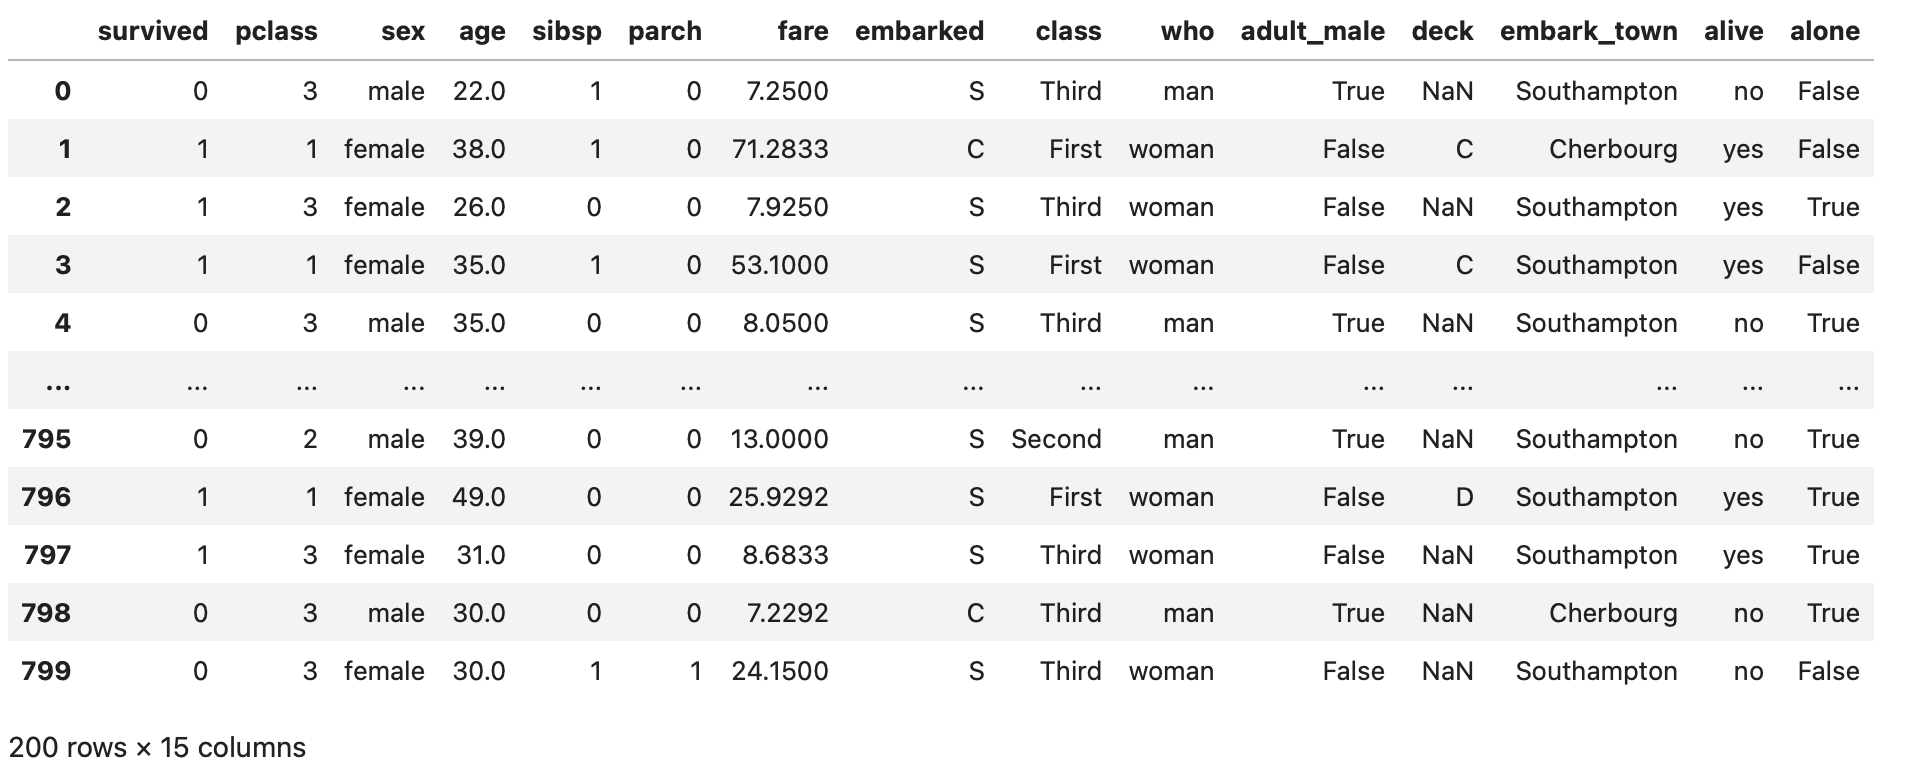

### 다음은 merge를 통해 공통 항목을 기준으로 병합을 해봅시다.  
서로 다른 데이터셋을 합칠 때 가장 자주 사용하는 방식이니 꼭 기억하세요!

In [98]:
#바로 실행해보세요
d3 = data3.iloc[4:14, 3:12:3]
d4 = data3.iloc[10:18, 3:12:2]

d3

,age,fare,who
4,35.0,8.0500,man
5,NaN,8.4583,man
6,54.0,51.8625,man
7,2.0,21.0750,child
8,27.0,11.1333,woman
9,14.0,30.0708,child
10,4.0,16.7000,child
11,58.0,26.5500,woman
12,20.0,8.0500,man
13,39.0,31.2750,man


In [99]:
d4

,age,parch,embarked,who,deck
10,4.0,1,S,child,G
11,58.0,0,S,woman,C
12,20.0,0,S,man,NaN
13,39.0,5,S,man,NaN
14,14.0,0,S,child,NaN
15,55.0,0,S,woman,NaN
16,2.0,1,Q,child,NaN
17,NaN,0,S,man,NaN


In [100]:
# 여기부터 문제입니다
# age 열을 기준으로 d3과 d4를 교집합 연산으로 합쳐봅시다
merge_data_inner= pd.merge(d3, d4, how='inner', on='age')

merge_data_inner

,age,fare,who_x,parch,embarked,who_y,deck
0,NaN,8.4583,man,0,S,man,NaN
1,2.0,21.0750,child,1,Q,child,NaN
2,14.0,30.0708,child,0,S,child,NaN
3,4.0,16.7000,child,1,S,child,G
4,58.0,26.5500,woman,0,S,woman,C
5,20.0,8.0500,man,0,S,man,NaN
6,39.0,31.2750,man,5,S,man,NaN


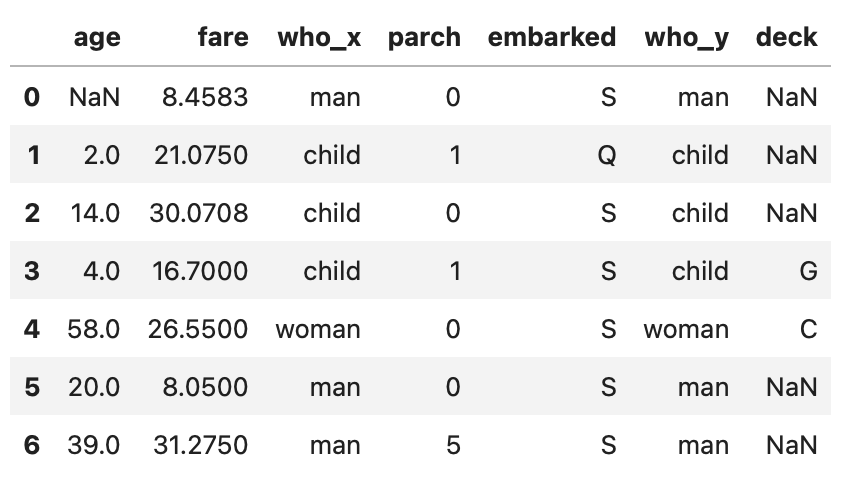

In [101]:
# 이번에는 age 열을 기준으로 d3과 d4를 합집합 연산으로 합쳐봅시다
merge_data_outer = pd.merge(d3, d4, how='outer', on='age')

merge_data_outer

,age,fare,who_x,parch,embarked,who_y,deck
0,2.0,21.0750,child,1.0,Q,child,NaN
1,4.0,16.7000,child,1.0,S,child,G
2,14.0,30.0708,child,0.0,S,child,NaN
3,20.0,8.0500,man,0.0,S,man,NaN
4,27.0,11.1333,woman,NaN,NaN,NaN,NaN
5,35.0,8.0500,man,NaN,NaN,NaN,NaN
6,39.0,31.2750,man,5.0,S,man,NaN
7,54.0,51.8625,man,NaN,NaN,NaN,NaN
8,55.0,NaN,NaN,0.0,S,woman,NaN
9,58.0,26.5500,woman,0.0,S,woman,C


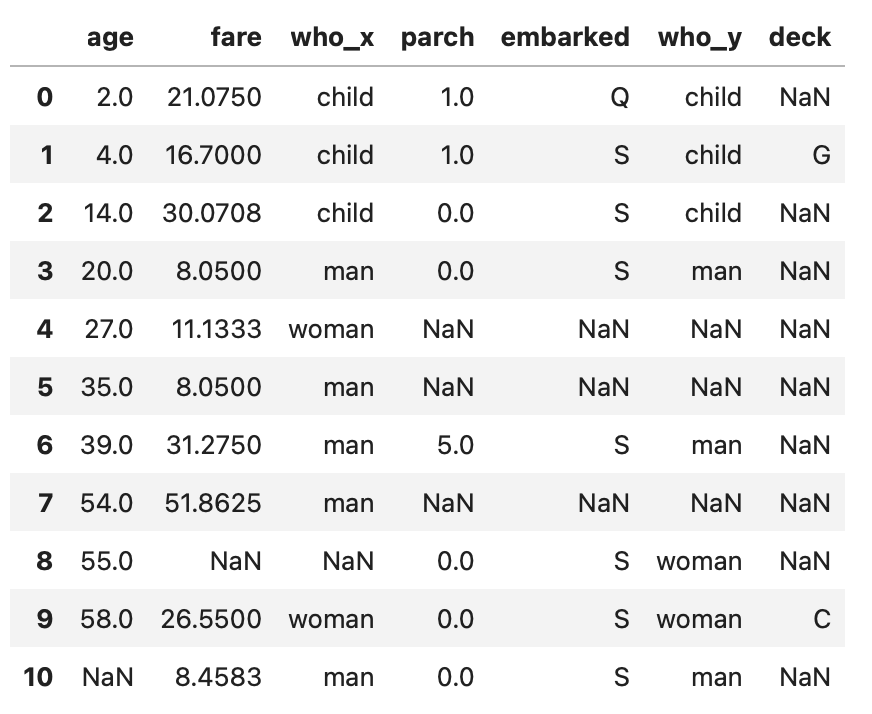

# 집계함수와 그룹화

## 집계 함수

In [102]:
#count(), min(), max(), sum(), mean() 등
data.count() # axis = 0이 default 값으로 설정되어 있습니다.

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

In [103]:
data[["age","fare"]].mean() # axis = 0이 default 값으로 설정되어 있습니다.

age     29.699118
fare    32.204208
dtype: float64

### GroupBy() 적용

In [104]:
data_groupby = data.groupby("pclass") # groupby만 사용하면 그룹화된 객체가 생성되지만, 이 자체만으로는 알 수 있는게 없습니다!
print(type(data_groupby))

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


In [105]:
data_groupby.count() # 따라서 groupby를 통해 인사이트를 얻으려면 집계함수와 같이 사용해줘야 합니다.

,survived,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
pclass,,,,,,,,,,,,,,
1,216,216,186,216,216,216,214,216,216,216,175,214,216,216
2,184,184,173,184,184,184,184,184,184,184,16,184,184,184
3,491,491,355,491,491,491,491,491,491,491,12,491,491,491


In [106]:
data.groupby(['pclass', 'survived']).size()

pclass  survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
dtype: int64

바로 위처럼 말이죠!!

### DataFrameGroupBy 객체에 [["pclass", "survived"]]로 필터링해서 count() 해주세요!

In [107]:
# DataFrameGroupBy 객체에 [["pclass", "survived"]]로 필터링해서 count() 옵션을 걸어보는 코드입니다
data_groupby = data.groupby('pclass')[['pclass','survived']].count()
data_groupby

,pclass,survived
pclass,,
1,216,216
2,184,184
3,491,491


In [108]:
#agg()를 이용해 여러 함수를 동시에 구현도 가능
agg_format = {"age":"max", "sibsp":"sum", "fare":"mean"}
data.groupby("pclass").agg(agg_format)

,age,sibsp,fare
pclass,,,
1,80.0,90,84.154687
2,70.0,74,20.662183
3,74.0,302,13.675550


고생하셨습니다!